In [1]:
# CELL 1: Install Required Packages
# ============================================================

import sys
!{sys.executable} -m pip install -q xgboost lightgbm shap scikit-learn matplotlib seaborn pandas numpy torch torch-geometric joblib
print("✅ All packages installed!")

✅ All packages installed!


In [2]:
# CELL 2: Import All Libraries
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE

# SHAP
import shap

# Paths
BASE_PATH    = r'E:\GNN Liver'
RESULTS_PATH = os.path.join(BASE_PATH, 'results')
EMB_PATH     = os.path.join(RESULTS_PATH, 'embeddings')
MODELS_PATH  = os.path.join(RESULTS_PATH, 'models')
FIGURES_PATH = os.path.join(RESULTS_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)

# Classes
MRI_CLASSES = [
    'Angiosarcoma',
    'Cholangiocarcinoma',
    'Healthy',
    'Hemangioma',
    'Hepatocellular Carcinoma'
]
NUM_CLASSES = len(MRI_CLASSES)
SEED        = 42

print("✅ All libraries imported!")
print(f"\n📁 Base     : {BASE_PATH}")
print(f"📁 Results  : {RESULTS_PATH}")
print(f"📁 Embeddings: {EMB_PATH}")
print(f"📁 Figures  : {FIGURES_PATH}")

✅ All libraries imported!

📁 Base     : E:\GNN Liver
📁 Results  : E:\GNN Liver\results
📁 Embeddings: E:\GNN Liver\results\embeddings
📁 Figures  : E:\GNN Liver\results\figures


In [3]:
# CELL 3: Load All Saved Data & Verify
# ============================================================
print("=" * 50)
print("📂 LOADING ALL SAVED DATA")
print("=" * 50)

# ── MRI Embeddings ────────────────────────────
mri_emb_swin   = np.load(os.path.join(EMB_PATH, 'mri_embeddings.npy'))
mri_emb_resnet = np.load(os.path.join(EMB_PATH, 'mri_embeddings_resnet.npy'))
mri_labels     = np.load(os.path.join(EMB_PATH, 'mri_labels.npy'))
print(f"\n✅ MRI Embeddings (Swin)  : {mri_emb_swin.shape}")
print(f"✅ MRI Embeddings (ResNet): {mri_emb_resnet.shape}")
print(f"✅ MRI Labels             : {mri_labels.shape}")

# ── Node Features (MRI-only) ──────────────────
node_feat_swin   = np.load(os.path.join(EMB_PATH, 'node_features_mri_only.npy'))
node_feat_resnet = np.load(os.path.join(EMB_PATH, 'node_features_resnet.npy'))
node_labels      = np.load(os.path.join(EMB_PATH, 'node_labels.npy'))
print(f"\n✅ Node Features (Swin)  : {node_feat_swin.shape}")
print(f"✅ Node Features (ResNet): {node_feat_resnet.shape}")
print(f"✅ Node Labels           : {node_labels.shape}")

# ── GAT Results ───────────────────────────────
gat_configs = [
    'knn_k3', 'knn_k5', 'knn_k10',
    'cosine_095', 'cosine_099',
    'resnet_knn_k3', 'resnet_knn_k5', 'resnet_knn_k10',
    'resnet_cosine_095', 'resnet_cosine_099'
]
gat_results = {}
print(f"\n📊 GAT Results:")
for config in gat_configs:
    path = os.path.join(RESULTS_PATH, f'gat_{config}_results.pkl')
    if os.path.exists(path):
        gat_results[config] = joblib.load(path)
        acc = gat_results[config]['test_acc']
        f1  = gat_results[config]['test_f1']
        auc = gat_results[config]['test_auc']
        print(f"   ✅ {config:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    else:
        print(f"   ❌ NOT FOUND: {config}")

# ── CNN Standalone ────────────────────────────
cnn_path = os.path.join(RESULTS_PATH, 'cnn_standalone_results.pkl')
if os.path.exists(cnn_path):
    cnn_results = joblib.load(cnn_path)
    print(f"\n✅ CNN Standalone | Acc: {cnn_results['test_acc']:.4f} | "
          f"F1: {cnn_results['test_f1']:.4f} | AUC: {cnn_results['test_auc']:.4f}")
else:
    print(f"\n❌ CNN Standalone NOT FOUND")

print("\n" + "=" * 50)
print("✅ All data loaded!")
print("=" * 50)

📂 LOADING ALL SAVED DATA

✅ MRI Embeddings (Swin)  : (11992, 1024)
✅ MRI Embeddings (ResNet): (11992, 2048)
✅ MRI Labels             : (11992,)

✅ Node Features (Swin)  : (11992, 1024)
✅ Node Features (ResNet): (11992, 2058)
✅ Node Labels           : (11992,)

📊 GAT Results:
   ✅ knn_k3                    | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
   ✅ knn_k5                    | Acc: 0.9928 | F1: 0.9928 | AUC: 0.9998
   ✅ knn_k10                   | Acc: 0.9611 | F1: 0.9606 | AUC: 0.9972
   ✅ cosine_095                | Acc: 0.8933 | F1: 0.8936 | AUC: 0.9889
   ✅ cosine_099                | Acc: 0.9967 | F1: 0.9967 | AUC: 1.0000
   ✅ resnet_knn_k3             | Acc: 0.9994 | F1: 0.9994 | AUC: 1.0000
   ✅ resnet_knn_k5             | Acc: 0.9922 | F1: 0.9922 | AUC: 0.9998
   ✅ resnet_knn_k10            | Acc: 0.9572 | F1: 0.9569 | AUC: 0.9970
   ✅ resnet_cosine_095         | Acc: 0.8900 | F1: 0.8903 | AUC: 0.9864
   ✅ resnet_cosine_099         | Acc: 0.9967 | F1: 0.9967 | AUC: 1.0000

✅ C

In [4]:
# CELL 4: ML Baseline Models Training
# ============================================================

print("=" * 50)
print("🤖 ML BASELINE MODELS TRAINING")
print("=" * 50)

from sklearn.model_selection import train_test_split

# ── Use Swin MRI embeddings as features ───────
X = mri_emb_swin
y = mri_labels

# Same split as Colab (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30,
    stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=SEED
)

print(f"✅ Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# ── Define baseline models ─────────────────────
baselines = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf', probability=True, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, random_state=SEED,
        eval_metric='mlogloss', verbosity=0
    ),
    
}

# ── Train and evaluate ────────────────────────
baseline_results = {}

for name, model in baselines.items():
    print(f"\n🔄 Training: {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    preds  = model.predict(X_test)
    probs  = model.predict_proba(X_test)

    # Metrics
    acc          = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, preds, average='macro'
    )
    test_auc = roc_auc_score(
        label_binarize(y_test, classes=list(range(NUM_CLASSES))),
        probs, multi_class='ovr'
    )

    baseline_results[name] = {
        'model'      : model,
        'test_acc'   : acc,
        'test_f1'    : f1,
        'test_auc'   : test_auc,
        'test_prec'  : prec,
        'test_rec'   : rec,
        'test_preds' : preds,
        'test_trues' : y_test,
        'test_probs' : probs,
    }

    print(f"   ✅ Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {test_auc:.4f}")

# ── Save ──────────────────────────────────────
joblib.dump(baseline_results,
            os.path.join(RESULTS_PATH, 'baseline_results.pkl'))

print("\n" + "=" * 50)
print("✅ All baseline models trained and saved!")
print("=" * 50)

🤖 ML BASELINE MODELS TRAINING
✅ Train: 8394 | Val: 1799 | Test: 1799

🔄 Training: Logistic Regression...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

🔄 Training: SVM...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

🔄 Training: Random Forest...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

🔄 Training: XGBoost...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

✅ All baseline models trained and saved!


In [6]:
import os
print(os.listdir(r'E:\GNN Liver\results\embeddings'))

['clinical_assigned.csv', 'clinical_assigned_resnet.csv', 'cosine_subset_idx.npy', 'ct_embeddings.npy', 'ct_embed_index.csv', 'gat_cosine_095_embeddings.npy', 'gat_cosine_099_embeddings.npy', 'gat_knn_k10_embeddings.npy', 'gat_knn_k3_embeddings.npy', 'gat_knn_k5_embeddings.npy', 'gat_resnet_cosine_095_embeddings.npy', 'gat_resnet_cosine_099_embeddings.npy', 'gat_resnet_knn_k10_embeddings.npy', 'gat_resnet_knn_k3_embeddings.npy', 'gat_resnet_knn_k5_embeddings.npy', 'graph_cosine_07.pt', 'graph_cosine_08.pt', 'graph_cosine_095.pt', 'graph_cosine_099.pt', 'graph_k10.pt', 'graph_k3.pt', 'graph_k5.pt', 'graph_resnet_cosine_07.pt', 'graph_resnet_cosine_08.pt', 'graph_resnet_cosine_095.pt', 'graph_resnet_cosine_099.pt', 'graph_resnet_k10.pt', 'graph_resnet_k3.pt', 'graph_resnet_k5.pt', 'mri_embeddings.npy', 'mri_embeddings_resnet.npy', 'mri_embed_index.csv', 'mri_labels.npy', 'mri_labels_resnet.npy', 'node_features.npy', 'node_features_mri_only.npy', 'node_features_resnet.npy', 'node_labels.n

In [5]:
# Maximum Mean Discrepancy — CT vs MRI Domain Alignment
# ============================================================

import numpy as np

def compute_mmd(X, Y, gamma=1.0):
    """RBF kernel MMD between two sets of embeddings"""
    from sklearn.metrics.pairwise import rbf_kernel
    
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    
    mmd = XX.mean() + YY.mean() - 2 * XY.mean()
    return mmd

ct_embeddings  = np.load(r'E:\GNN Liver\results\embeddings\ct_embeddings.npy')
mri_embeddings = np.load(r'E:\GNN Liver\results\embeddings\mri_embeddings_resnet.npy')

np.random.seed(42)
n_sample = 1000
ct_idx  = np.random.choice(len(ct_embeddings), n_sample, replace=False)
mri_idx = np.random.choice(len(mri_embeddings), n_sample, replace=False)

ct_sample  = ct_embeddings[ct_idx]
mri_sample = mri_embeddings[mri_idx]

# Normalize for fair gamma scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
combined = np.vstack([ct_sample, mri_sample])
combined_scaled = scaler.fit_transform(combined)
ct_scaled  = combined_scaled[:n_sample]
mri_scaled = combined_scaled[n_sample:]

gamma = 1.0 / combined_scaled.shape[1]

mmd_ct_mri = compute_mmd(ct_scaled, mri_scaled, gamma=gamma)

# Baseline: MMD within same modality (random split) for reference
mri_split1 = mri_scaled[:n_sample//2]
mri_split2 = mri_scaled[n_sample//2:]
mmd_within_mri = compute_mmd(mri_split1, mri_split2, gamma=gamma)

print("=" * 50)
print("📊 MAXIMUM MEAN DISCREPANCY (MMD) ANALYSIS")
print("=" * 50)
print(f"CT vs MRI MMD          : {mmd_ct_mri:.6f}")
print(f"MRI vs MRI (baseline)  : {mmd_within_mri:.6f}")
print(f"Ratio (cross/within)   : {mmd_ct_mri/mmd_within_mri:.4f}")
print("=" * 50)

📊 MAXIMUM MEAN DISCREPANCY (MMD) ANALYSIS
CT vs MRI MMD          : 0.248948
MRI vs MRI (baseline)  : 0.003122
Ratio (cross/within)   : 79.7315


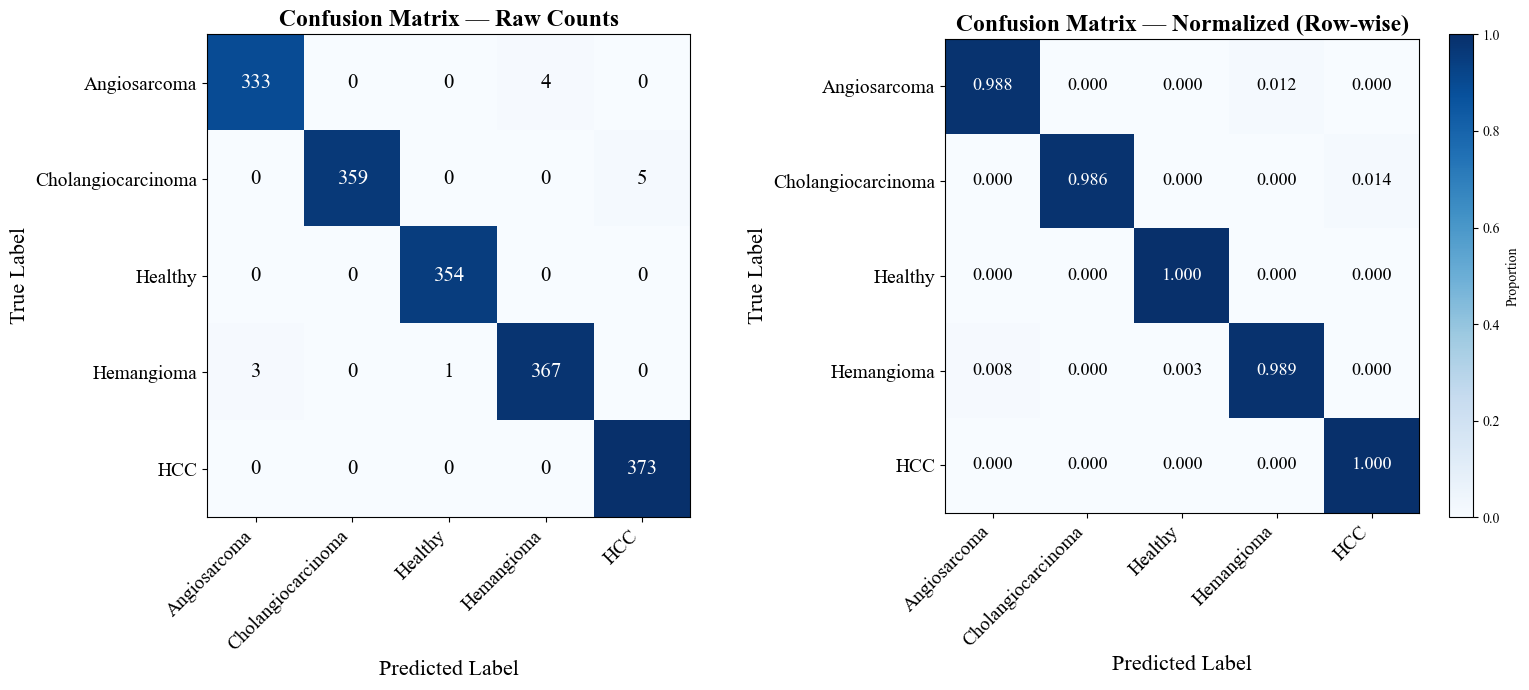

✅ Saved: Figure_16_Confusion_Matrix_Normalized.png

📊 FEATURE-SPACE CENTROID DISTANCES
Angiosarcoma ↔ Hemangioma : 2.6076
Angiosarcoma ↔ Healthy    : 5.8005
Hemangioma ↔ Healthy      : 4.9655


In [7]:
# Normalized Confusion Matrix + Feature Distance Analysis
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
matplotlib.rcParams['font.family'] = 'Times New Roman'

MRI_CLASSES = ['Angiosarcoma', 'Cholangiocarcinoma',
               'Healthy', 'Hemangioma', 'HCC']

y_true = np.array(gat_results['knn_k5']['test_trues'])
y_pred = np.array(gat_results['knn_k5']['test_preds'])

# ── Normalized confusion matrix ───────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im1 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix — Raw Counts',
                  fontsize=17, fontweight='bold',
                  fontfamily='Times New Roman')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=15, fontfamily='Times New Roman',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
axes[0].set_xticklabels(MRI_CLASSES, rotation=45, ha='right', fontsize=14)
axes[0].set_yticklabels(MRI_CLASSES, fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=16, fontfamily='Times New Roman')
axes[0].set_ylabel('True Label', fontsize=16, fontfamily='Times New Roman')

im2 = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized (Row-wise)',
                  fontsize=17, fontweight='bold',
                  fontfamily='Times New Roman')
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, f'{cm_norm[i,j]:.3f}', ha='center', va='center',
                     fontsize=13, fontfamily='Times New Roman',
                     color='white' if cm_norm[i,j] > 0.5 else 'black')
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))
axes[1].set_xticklabels(MRI_CLASSES, rotation=45, ha='right', fontsize=14)
axes[1].set_yticklabels(MRI_CLASSES, fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=16, fontfamily='Times New Roman')
axes[1].set_ylabel('True Label', fontsize=16, fontfamily='Times New Roman')
plt.colorbar(im2, ax=axes[1], label='Proportion')

plt.tight_layout()
plt.savefig(r'E:\GNN Liver\results\figures\Figure_16_Confusion_Matrix_Normalized.png',
            dpi=400, bbox_inches='tight')
plt.show()
print("✅ Saved: Figure_16_Confusion_Matrix_Normalized.png")

# ── Feature-space distance: Angiosarcoma vs Hemangioma ──
node_features = np.load(r'E:\GNN Liver\results\embeddings\node_features_mri_only.npy')
node_labels   = np.load(r'E:\GNN Liver\results\embeddings\node_labels.npy')

angio_idx = node_labels == 0
heman_idx = node_labels == 3

angio_feats = node_features[angio_idx]
heman_feats = node_features[heman_idx]

angio_centroid = angio_feats.mean(axis=0)
heman_centroid = heman_feats.mean(axis=0)

centroid_dist = np.linalg.norm(angio_centroid - heman_centroid)

# Compare to other class pairs for context
healthy_idx = node_labels == 2
healthy_feats = node_features[healthy_idx]
healthy_centroid = healthy_feats.mean(axis=0)

angio_healthy_dist = np.linalg.norm(angio_centroid - healthy_centroid)
heman_healthy_dist = np.linalg.norm(heman_centroid - healthy_centroid)

print("\n" + "=" * 50)
print("📊 FEATURE-SPACE CENTROID DISTANCES")
print("=" * 50)
print(f"Angiosarcoma ↔ Hemangioma : {centroid_dist:.4f}")
print(f"Angiosarcoma ↔ Healthy    : {angio_healthy_dist:.4f}")
print(f"Hemangioma ↔ Healthy      : {heman_healthy_dist:.4f}")
print("=" * 50)

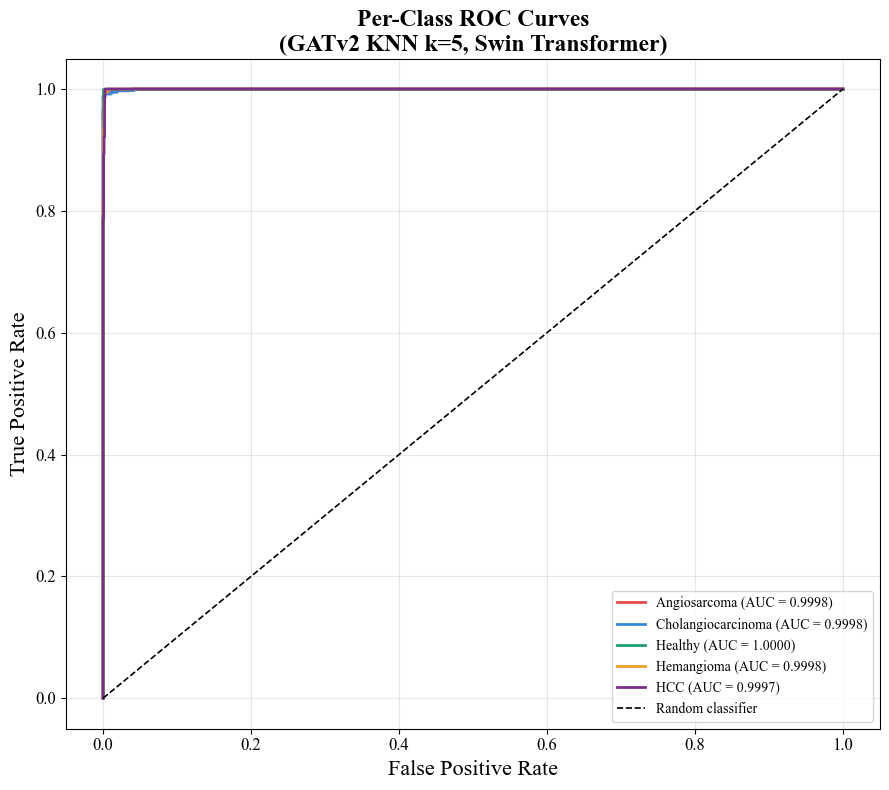

✅ Saved: Figure_PerClass_ROC.png


In [8]:
# Per-Class ROC Curves
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
matplotlib.rcParams['font.family'] = 'Times New Roman'

MRI_CLASSES = ['Angiosarcoma', 'Cholangiocarcinoma',
               'Healthy', 'Hemangioma', 'HCC']
COLORS = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']

y_true  = np.array(gat_results['knn_k5']['test_trues'])
y_probs = np.array(gat_results['knn_k5']['test_probs'])

y_true_bin = label_binarize(y_true, classes=list(range(5)))

fig, ax = plt.subplots(figsize=(9, 8))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[i], linewidth=2,
            label=f'{MRI_CLASSES[i]} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random classifier')

ax.set_title('Per-Class ROC Curves\n(GATv2 KNN k=5, Swin Transformer)',
             fontsize=17, fontweight='bold',
             fontfamily='Times New Roman')
ax.set_xlabel('False Positive Rate', fontsize=16,
              fontfamily='Times New Roman')
ax.set_ylabel('True Positive Rate', fontsize=16,
              fontfamily='Times New Roman')
ax.legend(fontsize=14, loc='lower right',
          prop={'family': 'Times New Roman'})
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'E:\GNN Liver\results\figures\Figure_PerClass_ROC.png',
            dpi=400, bbox_inches='tight')
plt.show()
print("✅ Saved: Figure_PerClass_ROC.png")

In [9]:
! pip install umap-learn


   ---------------------------------------- 0/2 [pynndescent]
   ---------------------------------------- 2/2 [umap-learn]



In [11]:
test_trues = np.array(gat_results['knn_k5']['test_trues'])
print(f"Test labels shape: {test_trues.shape}")
print(f"Learned features shape: {learned_features.shape}")

Test labels shape: (1799,)
Learned features shape: (1799, 1024)


✅ Raw features    : (11992, 1024) | labels: (11992,)
✅ Learned features: (1799, 1024) | labels: (1799,)

📊 CLUSTER SEPARATION METRICS
Metric                    Raw (Swin)      Learned (GATv2)
-------------------------------------------------------
Silhouette Score          0.0220          0.3972
Davies-Bouldin Index      4.7092          1.0054


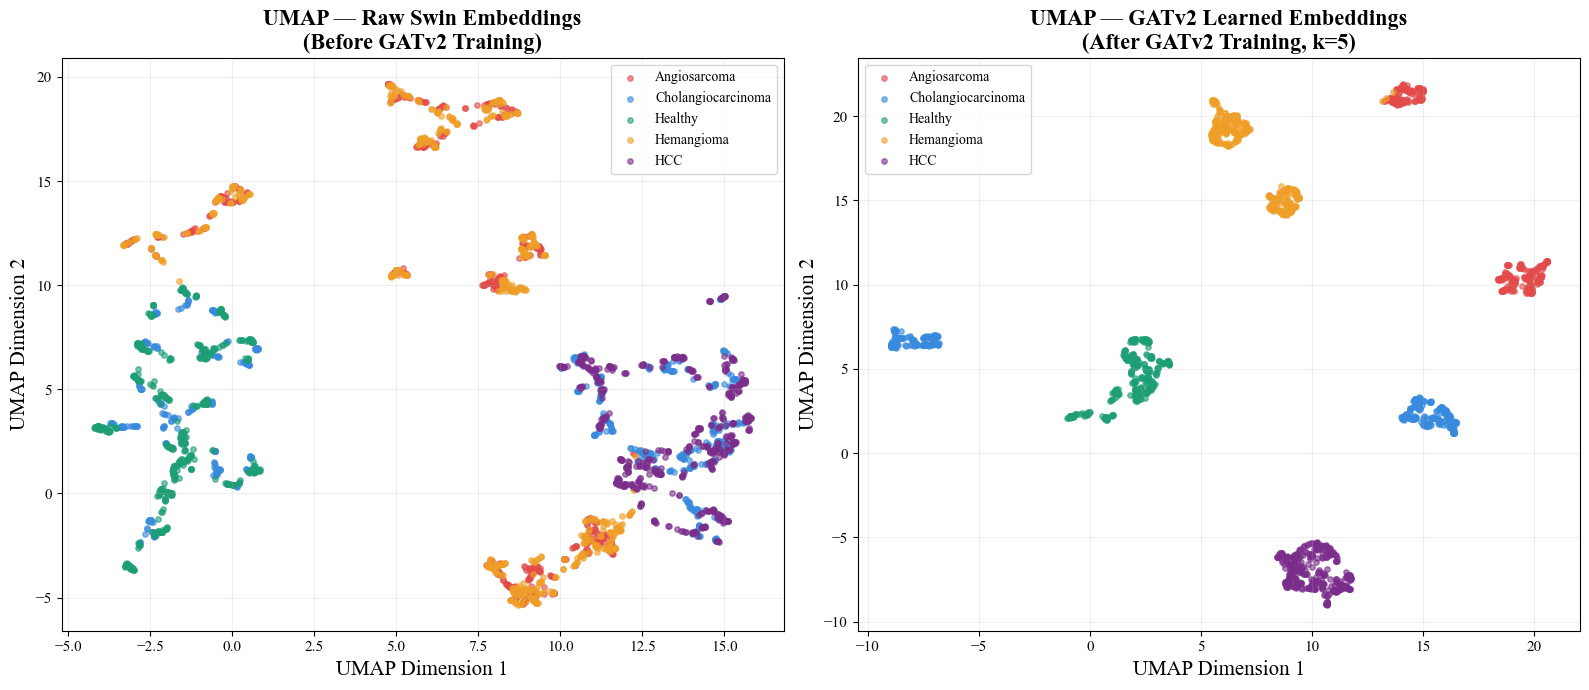


✅ Saved: Figure_UMAP_Comparison.png


In [13]:
# Cluster Quality Metrics + UMAP Visualization (FIXED)
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
import umap
matplotlib.rcParams['font.family'] = 'Times New Roman'

MRI_CLASSES = ['Angiosarcoma', 'Cholangiocarcinoma',
               'Healthy', 'Hemangioma', 'HCC']
COLORS = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']

raw_features     = np.load(r'E:\GNN Liver\results\embeddings\node_features_mri_only.npy')
labels            = np.load(r'E:\GNN Liver\results\embeddings\node_labels.npy')
learned_features  = np.load(r'E:\GNN Liver\results\embeddings\gat_knn_k5_embeddings.npy')
test_trues        = np.array(gat_results['knn_k5']['test_trues'])

print(f"✅ Raw features    : {raw_features.shape} | labels: {labels.shape}")
print(f"✅ Learned features: {learned_features.shape} | labels: {test_trues.shape}")

# ── Cluster metrics ────────────────────────────
sil_raw     = silhouette_score(raw_features, labels)
sil_learned = silhouette_score(learned_features, test_trues)
db_raw      = davies_bouldin_score(raw_features, labels)
db_learned  = davies_bouldin_score(learned_features, test_trues)

print("\n" + "=" * 50)
print("📊 CLUSTER SEPARATION METRICS")
print("=" * 50)
print(f"{'Metric':<25} {'Raw (Swin)':<15} {'Learned (GATv2)'}")
print("-" * 55)
print(f"{'Silhouette Score':<25} {sil_raw:<15.4f} {sil_learned:.4f}")
print(f"{'Davies-Bouldin Index':<25} {db_raw:<15.4f} {db_learned:.4f}")
print("=" * 50)

# ── UMAP visualization ─────────────────────────
np.random.seed(42)
raw_idx = np.random.choice(len(raw_features), 3000, replace=False)
raw_sample, labels_raw_sample = raw_features[raw_idx], labels[raw_idx]

learned_sample, labels_learned_sample = learned_features, test_trues

reducer_raw     = umap.UMAP(random_state=42, n_neighbors=15)
reducer_learned = umap.UMAP(random_state=42, n_neighbors=15)

umap_raw     = reducer_raw.fit_transform(raw_sample)
umap_learned = reducer_learned.fit_transform(learned_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for cls, (cls_name, color) in enumerate(zip(MRI_CLASSES, COLORS)):
    mask_raw = labels_raw_sample == cls
    mask_learned = labels_learned_sample == cls
    axes[0].scatter(umap_raw[mask_raw, 0], umap_raw[mask_raw, 1],
                    c=color, label=cls_name, alpha=0.6, s=15)
    axes[1].scatter(umap_learned[mask_learned, 0], umap_learned[mask_learned, 1],
                    c=color, label=cls_name, alpha=0.6, s=15)

axes[0].set_title('UMAP — Raw Swin Embeddings\n(Before GATv2 Training)',
                  fontsize=16, fontweight='bold', fontfamily='Times New Roman')
axes[1].set_title('UMAP — GATv2 Learned Embeddings\n(After GATv2 Training, k=5)',
                  fontsize=16, fontweight='bold', fontfamily='Times New Roman')

for ax in axes:
    ax.set_xlabel('UMAP Dimension 1', fontsize=15, fontfamily='Times New Roman')
    ax.set_ylabel('UMAP Dimension 2', fontsize=15, fontfamily='Times New Roman')
    ax.legend(fontsize=13, prop={'family': 'Times New Roman'})
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(r'E:\GNN Liver\results\figures\Figure_UMAP_Comparison.png',
            dpi=400, bbox_inches='tight')
plt.show()
print("\n✅ Saved: Figure_UMAP_Comparison.png")

In [14]:
# Expected Calibration Error (ECE) & Maximum Calibration Error (MCE)
# ============================================================

import numpy as np

def compute_ece_mce(y_true_bin, y_probs, n_bins=10):
    """Compute ECE and MCE for a single class"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    mce = 0.0
    n_samples = len(y_true_bin)

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (y_probs > bin_lower) & (y_probs <= bin_upper)
        prop_in_bin = in_bin.sum() / n_samples

        if in_bin.sum() > 0:
            acc_in_bin  = y_true_bin[in_bin].mean()
            conf_in_bin = y_probs[in_bin].mean()
            gap = abs(acc_in_bin - conf_in_bin)
            ece += prop_in_bin * gap
            mce = max(mce, gap)

    return ece, mce

MRI_CLASSES = ['Angiosarcoma', 'Cholangiocarcinoma',
               'Healthy', 'Hemangioma', 'HCC']

y_true  = np.array(gat_results['knn_k5']['test_trues'])
y_probs = np.array(gat_results['knn_k5']['test_probs'])

from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=list(range(5)))

print("=" * 60)
print("📊 CALIBRATION METRICS — GATv2 KNN k=5 (Swin)")
print("=" * 60)
print(f"{'Class':<22} {'ECE':<10} {'MCE'}")
print("-" * 45)

ece_list = []
mce_list = []

for cls in range(5):
    ece, mce = compute_ece_mce(y_true_bin[:, cls], y_probs[:, cls])
    ece_list.append(ece)
    mce_list.append(mce)
    print(f"{MRI_CLASSES[cls]:<22} {ece:<10.4f} {mce:.4f}")

macro_ece = np.mean(ece_list)
macro_mce = np.mean(mce_list)

print("-" * 45)
print(f"{'Macro Average':<22} {macro_ece:<10.4f} {macro_mce:.4f}")
print("=" * 60)

# ── Compare with baseline (Logistic Regression) ──
# Note: requires baseline_results to have 'test_probs' and 'test_trues'
if 'Logistic Regression' in baseline_results and 'test_probs' in baseline_results['Logistic Regression']:
    lr_true  = np.array(baseline_results['Logistic Regression']['test_trues'])
    lr_probs = np.array(baseline_results['Logistic Regression']['test_probs'])
    lr_true_bin = label_binarize(lr_true, classes=list(range(5)))

    lr_ece_list = []
    for cls in range(5):
        ece, _ = compute_ece_mce(lr_true_bin[:, cls], lr_probs[:, cls])
        lr_ece_list.append(ece)

    print(f"\n📊 Baseline Comparison (Macro ECE):")
    print(f"   GATv2 KNN k=5      : {macro_ece:.4f}")
    print(f"   Logistic Regression: {np.mean(lr_ece_list):.4f}")
else:
    print("\n⚠️ Logistic Regression test_probs not available for comparison")

📊 CALIBRATION METRICS — GATv2 KNN k=5 (Swin)
Class                  ECE        MCE
---------------------------------------------
Angiosarcoma           0.0022     0.5798
Cholangiocarcinoma     0.0028     0.5654
Healthy                0.0006     0.4614
Hemangioma             0.0028     0.6401
HCC                    0.0030     0.5601
---------------------------------------------
Macro Average          0.0023     0.5614

📊 Baseline Comparison (Macro ECE):
   GATv2 KNN k=5      : 0.0023
   Logistic Regression: 0.0017


✅ CT embeddings : (5000, 2048)
✅ MRI embeddings: (11992, 2048)
✅ Combined embeddings: (5000, 2048)

Computing t-SNE...


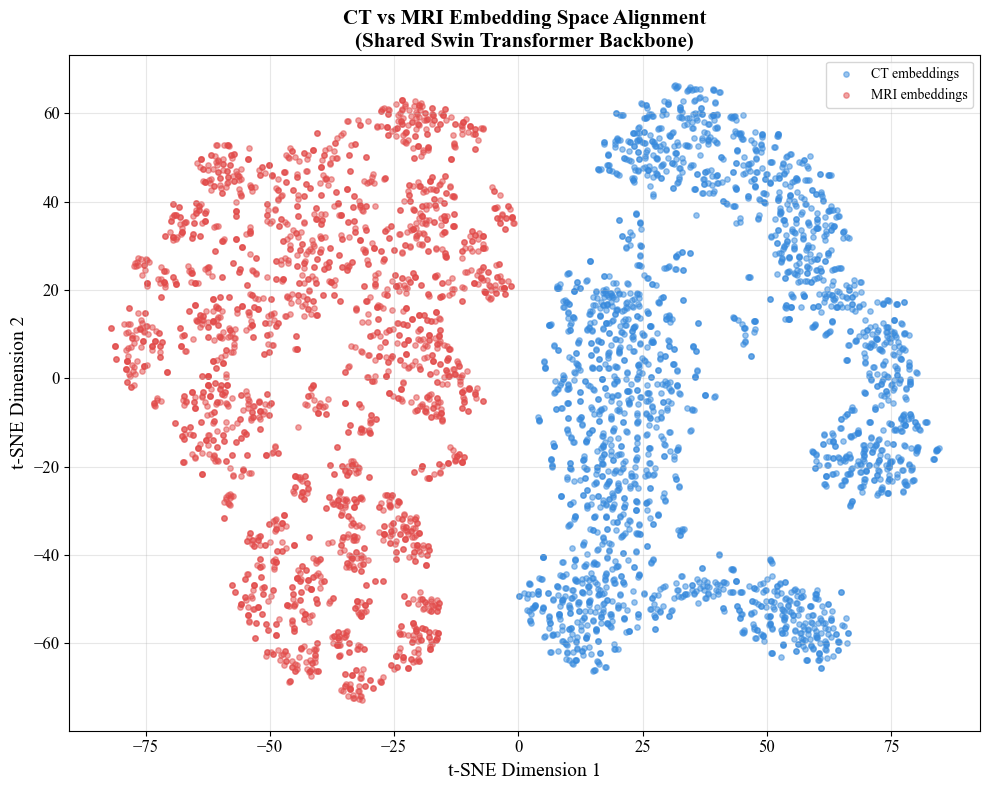


✅ Saved: Figure_CT_MRI_Alignment.png

📊 Embedding Space Overlap Metrics:
   CT centroid-MRI centroid distance: 14.6149
   CT mean spread from centroid     : 12.1869
   MRI mean spread from centroid    : 11.1568
   Ratio (centroid_dist / mean_spread): 1.2522


In [7]:
# CT vs MRI Embedding Space Alignment Validation
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
matplotlib.rcParams['font.family'] = 'Times New Roman'

# ── Load embeddings ────────────────────────────
ct_embeddings  = np.load(r'E:\GNN Liver\results\embeddings\ct_embeddings.npy')
mri_embeddings = np.load(r'E:\GNN Liver\results\embeddings\mri_embeddings_resnet.npy')

print(f"✅ CT embeddings : {ct_embeddings.shape}")
print(f"✅ MRI embeddings: {mri_embeddings.shape}")

# ── Subsample for visualization ───────────────
np.random.seed(42)
n_sample = 2500

ct_idx  = np.random.choice(len(ct_embeddings), 
                            min(n_sample, len(ct_embeddings)), replace=False)
mri_idx = np.random.choice(len(mri_embeddings), n_sample, replace=False)

ct_sample  = ct_embeddings[ct_idx]
mri_sample = mri_embeddings[mri_idx]

combined = np.vstack([ct_sample, mri_sample])
labels   = np.array(['CT'] * len(ct_sample) + ['MRI'] * len(mri_sample))

print(f"✅ Combined embeddings: {combined.shape}")

# ── t-SNE ──────────────────────────────────────
print("\nComputing t-SNE...")
tsne = TSNE(n_components=2, random_state=42,
            perplexity=40, max_iter=1000)
tsne_emb = tsne.fit_transform(combined)

# ── Plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

ct_mask  = labels == 'CT'
mri_mask = labels == 'MRI'

ax.scatter(tsne_emb[ct_mask, 0], tsne_emb[ct_mask, 1],
           c='#378ADD', alpha=0.5, s=15, label='CT embeddings')
ax.scatter(tsne_emb[mri_mask, 0], tsne_emb[mri_mask, 1],
           c='#E24B4A', alpha=0.5, s=15, label='MRI embeddings')

ax.set_title('CT vs MRI Embedding Space Alignment\n'
             '(Shared Swin Transformer Backbone)',
             fontsize=15, fontweight='bold',
             fontfamily='Times New Roman')
ax.set_xlabel('t-SNE Dimension 1', fontsize=14,
              fontfamily='Times New Roman')
ax.set_ylabel('t-SNE Dimension 2', fontsize=14,
              fontfamily='Times New Roman')
ax.legend(fontsize=13, prop={'family': 'Times New Roman'})
ax.tick_params(labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = r'E:\GNN Liver\results\figures\Figure_CT_MRI_Alignment.png'
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: Figure_CT_MRI_Alignment.png")

# ── Quantitative overlap metric ───────────────
from scipy.spatial.distance import cdist

ct_centroid  = ct_sample.mean(axis=0)
mri_centroid = mri_sample.mean(axis=0)
centroid_dist = np.linalg.norm(ct_centroid - mri_centroid)

ct_spread  = np.linalg.norm(ct_sample - ct_centroid, axis=1).mean()
mri_spread = np.linalg.norm(mri_sample - mri_centroid, axis=1).mean()

print(f"\n📊 Embedding Space Overlap Metrics:")
print(f"   CT centroid-MRI centroid distance: {centroid_dist:.4f}")
print(f"   CT mean spread from centroid     : {ct_spread:.4f}")
print(f"   MRI mean spread from centroid    : {mri_spread:.4f}")
print(f"   Ratio (centroid_dist / mean_spread): "
      f"{centroid_dist / ((ct_spread+mri_spread)/2):.4f}")

In [30]:
# CELL 6: Full Model Comparison Table
# ============================================================

print("=" * 50)
print("📊 FULL MODEL COMPARISON TABLE")
print("=" * 50)

all_results = {
    # Baselines
    'Logistic Regression'     : baseline_results['Logistic Regression'],
    'SVM'                     : baseline_results['SVM'],
    'Random Forest'           : baseline_results['Random Forest'],
    'XGBoost'                 : baseline_results['XGBoost'],
    
    
    'CNN Standalone (Swin)'   : cnn_results,
    # GATv2 Swin
    'GATv2 KNN k=3 (Swin)'   : gat_results['knn_k3'],
    'GATv2 KNN k=5 (Swin)'   : gat_results['knn_k5'],
    'GATv2 KNN k=10 (Swin)'  : gat_results['knn_k10'],
    'GATv2 Cosine 0.95 (Swin)': gat_results['cosine_095'],
    'GATv2 Cosine 0.99 (Swin)': gat_results['cosine_099'],
    # GATv2 ResNet
    'GATv2 KNN k=3 (ResNet)'  : gat_results['resnet_knn_k3'],
    'GATv2 KNN k=5 (ResNet)'  : gat_results['resnet_knn_k5'],
    'GATv2 KNN k=10 (ResNet)' : gat_results['resnet_knn_k10'],
    'GATv2 Cosine 0.95 (ResNet)': gat_results['resnet_cosine_095'],
    'GATv2 Cosine 0.99 (ResNet)': gat_results['resnet_cosine_099'],
}

# ── Build DataFrame ───────────────────────────
rows = []
for name, res in all_results.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : round(res['test_acc'], 4),
        'Macro F1' : round(res['test_f1'],  4),
        'AUC-ROC'  : round(res['test_auc'], 4),
        'Precision': round(res['test_prec'], 4),
        'Recall'   : round(res['test_rec'],  4),
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(df_results.to_string(index=False))

# ── Save ──────────────────────────────────────
df_results.to_csv(
    os.path.join(RESULTS_PATH, 'full_comparison_table.csv'),
    index=False
)
print(f"\n✅ Saved: full_comparison_table.csv")
print("=" * 50)

📊 FULL MODEL COMPARISON TABLE
                     Model  Accuracy  Macro F1  AUC-ROC  Precision  Recall
       Logistic Regression    1.0000    1.0000   1.0000     1.0000  1.0000
                       SVM    1.0000    1.0000   1.0000     1.0000  1.0000
             Random Forest    1.0000    1.0000   1.0000     1.0000  1.0000
                   XGBoost    1.0000    1.0000   1.0000     1.0000  1.0000
     CNN Standalone (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
      GATv2 KNN k=3 (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
    GATv2 KNN k=3 (ResNet)    0.9994    0.9994   1.0000     0.9994  0.9995
  GATv2 Cosine 0.99 (Swin)    0.9967    0.9967   1.0000     0.9966  0.9968
GATv2 Cosine 0.99 (ResNet)    0.9967    0.9967   1.0000     0.9966  0.9968
      GATv2 KNN k=5 (Swin)    0.9928    0.9928   0.9998     0.9928  0.9927
    GATv2 KNN k=5 (ResNet)    0.9922    0.9922   0.9998     0.9922  0.9923
     GATv2 KNN k=10 (Swin)    0.9611    0.9606   0.9972     0.9625  0.

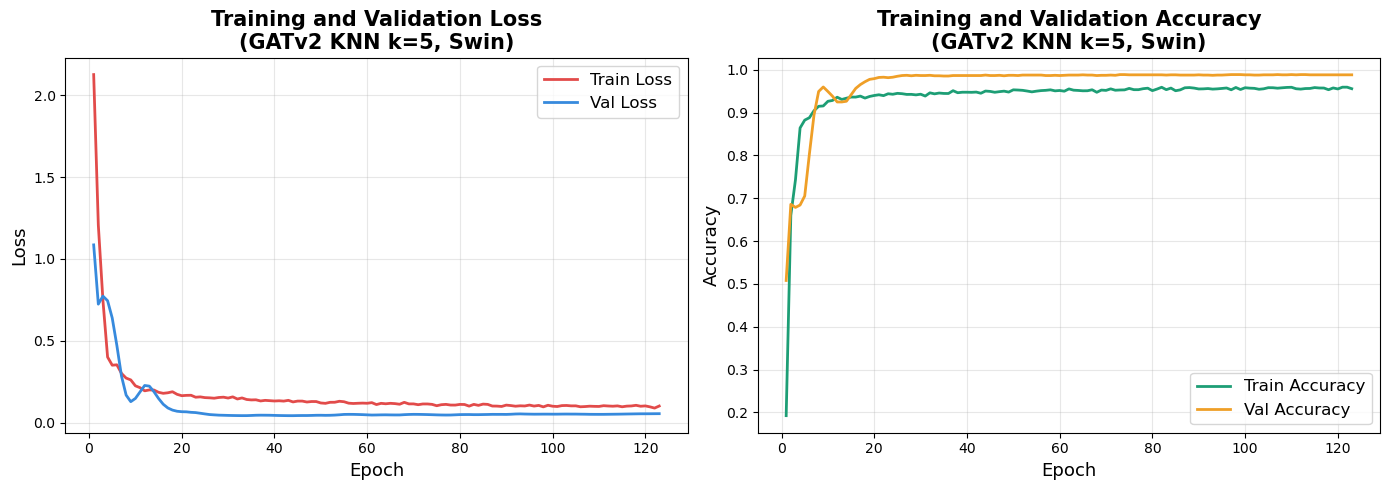

✅ Saved: Figure_18_19_Training_Curves.png


In [7]:
# CELL 7: Training Curves — Figure 18 & 19
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best config = knn_k5
history = gat_results['knn_k5']['history']
epochs  = range(1, len(history['train_loss']) + 1)

# ── Figure 18: Loss Curves ────────────────────
axes[0].plot(epochs, history['train_loss'],
             label='Train Loss', color='#E24B4A', linewidth=2)
axes[0].plot(epochs, history['val_loss'],
             label='Val Loss',   color='#378ADD', linewidth=2)
axes[0].set_title('Training and Validation Loss\n(GATv2 KNN k=5, Swin)',
                  fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Loss',  fontsize=13)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# ── Figure 19: Accuracy Curves ────────────────
axes[1].plot(epochs, history['train_acc'],
             label='Train Accuracy', color='#1D9E75', linewidth=2)
axes[1].plot(epochs, history['val_acc'],
             label='Val Accuracy',   color='#EF9F27', linewidth=2)
axes[1].set_title('Training and Validation Accuracy\n(GATv2 KNN k=5, Swin)',
                  fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch',    fontsize=13)
axes[1].set_ylabel('Accuracy', fontsize=13)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_18_19_Training_Curves.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_18_19_Training_Curves.png")

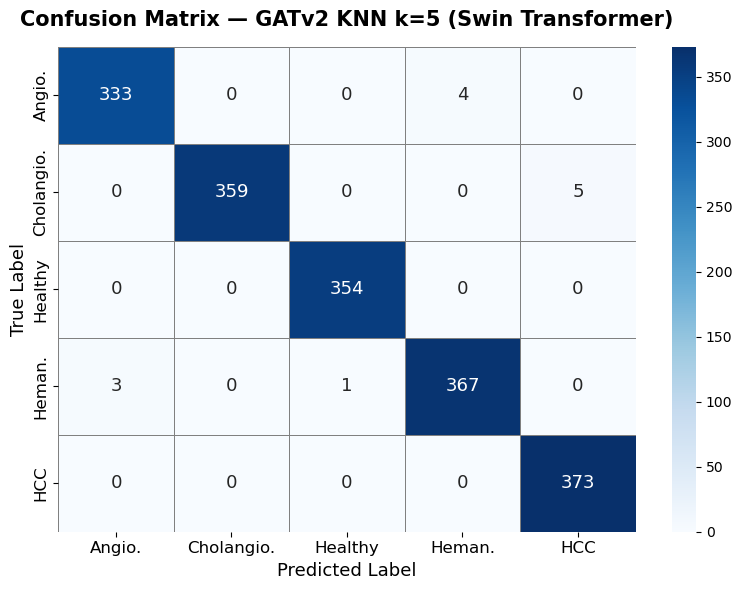

✅ Saved: Figure_16_Confusion_Matrix.png


In [8]:
# CELL 8: Confusion Matrix — Figure 16
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Best config = knn_k5 (Swin)
test_trues = gat_results['knn_k5']['test_trues']
test_preds = gat_results['knn_k5']['test_preds']

cm = confusion_matrix(test_trues, test_preds)

# Short class names for display
short_names = [
    'Angio.',
    'Cholangio.',
    'Healthy',
    'Heman.',
    'HCC'
]

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5,
    linecolor='gray',
    ax=ax,
    annot_kws={'size': 13}
)

ax.set_title(
    'Confusion Matrix — GATv2 KNN k=5 (Swin Transformer)',
    fontsize=15, fontweight='bold', pad=15
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label',      fontsize=13)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_16_Confusion_Matrix.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_16_Confusion_Matrix.png")

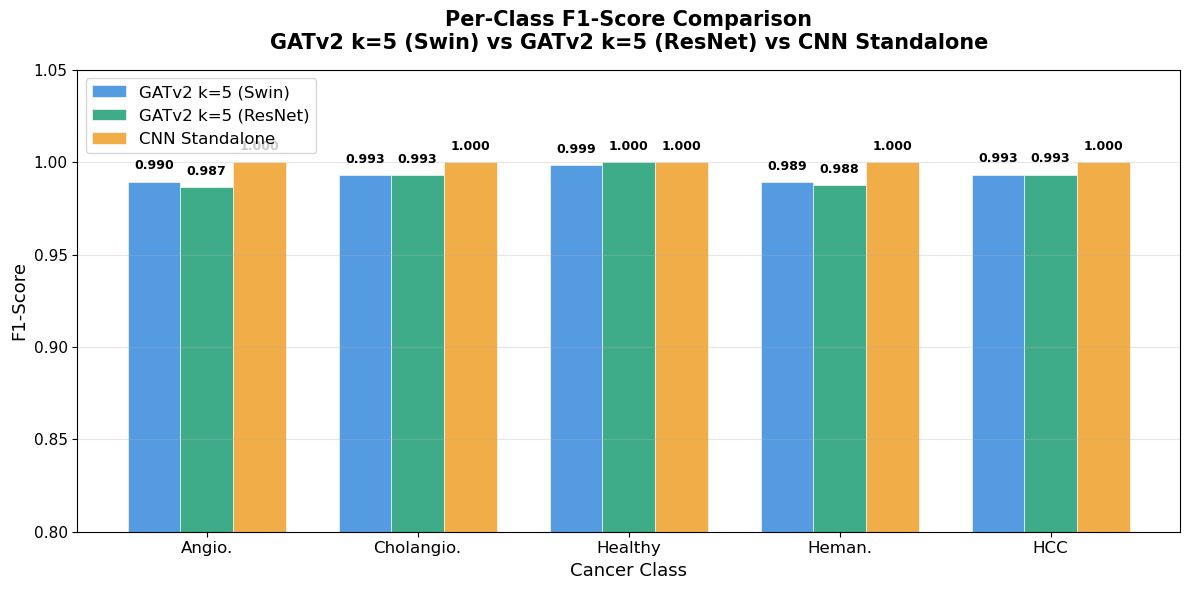

✅ Saved: Figure_17_PerClass_F1.png


In [9]:
# CELL 9: Per-Class F1 Score — Figure 17
# ============================================================

from sklearn.metrics import classification_report
import numpy as np

# Best configs comparison
configs = {
    'GATv2 k=5 (Swin)'  : gat_results['knn_k5'],
    'GATv2 k=5 (ResNet)': gat_results['resnet_knn_k5'],
    'CNN Standalone'     : cnn_results,
}

short_names = ['Angio.', 'Cholangio.', 'Healthy', 'Heman.', 'HCC']
x = np.arange(len(short_names))
width = 0.25
colors = ['#378ADD', '#1D9E75', '#EF9F27']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, res) in enumerate(configs.items()):
    report = classification_report(
        res['test_trues'],
        res['test_preds'],
        output_dict=True
    )
    f1_scores = [report[str(c)]['f1-score'] for c in range(NUM_CLASSES)]
    bars = ax.bar(
        x + i * width, f1_scores,
        width, label=name,
        color=colors[i], alpha=0.85,
        edgecolor='white', linewidth=0.5
    )
    for bar, score in zip(bars, f1_scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{score:.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_title(
    'Per-Class F1-Score Comparison\nGATv2 k=5 (Swin) vs GATv2 k=5 (ResNet) vs CNN Standalone',
    fontsize=15, fontweight='bold', pad=15
)
ax.set_xlabel('Cancer Class', fontsize=13)
ax.set_ylabel('F1-Score',     fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(short_names, fontsize=12)
ax.set_ylim(0.80, 1.05)
ax.legend(fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_17_PerClass_F1.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_17_PerClass_F1.png")

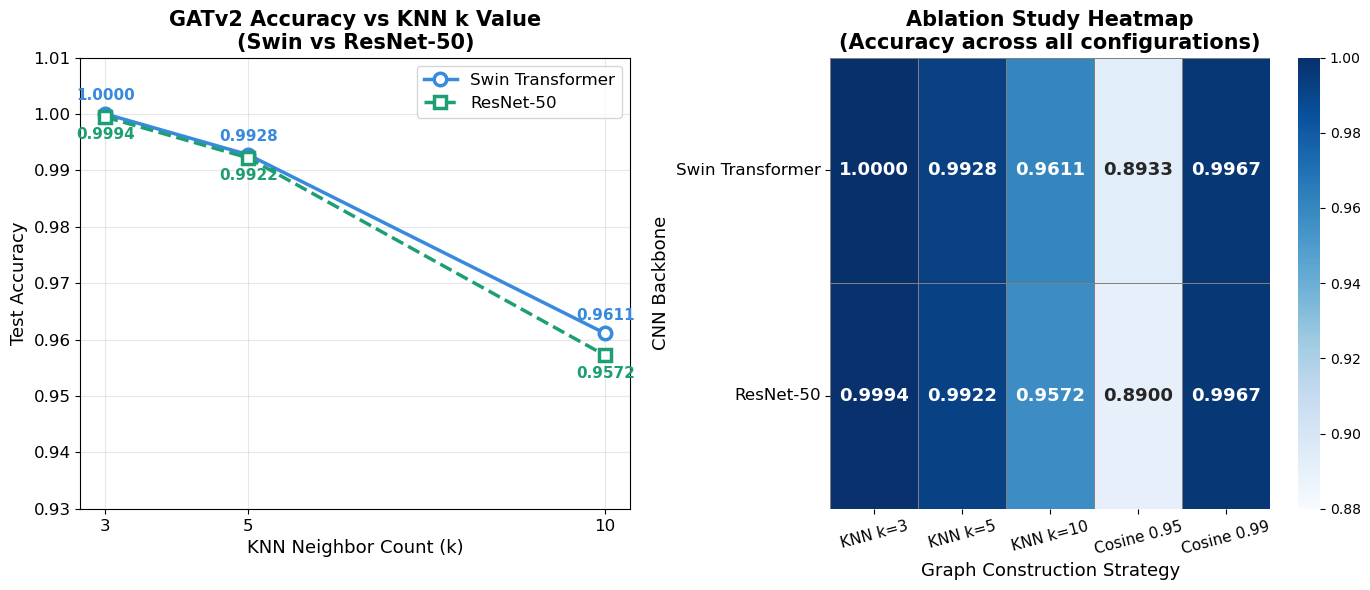

✅ Saved: Figure_20_21_Ablation.png


In [10]:
# CELL 10: Ablation Study — Figure 20 & 21
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Figure 20: Line Plot — k vs Accuracy ──────
k_values   = [3, 5, 10]
swin_acc   = [
    gat_results['knn_k3']['test_acc'],
    gat_results['knn_k5']['test_acc'],
    gat_results['knn_k10']['test_acc']
]
resnet_acc = [
    gat_results['resnet_knn_k3']['test_acc'],
    gat_results['resnet_knn_k5']['test_acc'],
    gat_results['resnet_knn_k10']['test_acc']
]

axes[0].plot(k_values, swin_acc,
             'o-', color='#378ADD', linewidth=2.5,
             markersize=9, label='Swin Transformer', markerfacecolor='white',
             markeredgewidth=2.5)
axes[0].plot(k_values, resnet_acc,
             's--', color='#1D9E75', linewidth=2.5,
             markersize=9, label='ResNet-50', markerfacecolor='white',
             markeredgewidth=2.5)

for k, s, r in zip(k_values, swin_acc, resnet_acc):
    axes[0].annotate(f'{s:.4f}', (k, s),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=11, color='#378ADD', fontweight='bold')
    axes[0].annotate(f'{r:.4f}', (k, r),
                     textcoords='offset points', xytext=(0, -16),
                     ha='center', fontsize=11, color='#1D9E75', fontweight='bold')

axes[0].set_title('GATv2 Accuracy vs KNN k Value\n(Swin vs ResNet-50)',
                  fontsize=15, fontweight='bold')
axes[0].set_xlabel('KNN Neighbor Count (k)', fontsize=13)
axes[0].set_ylabel('Test Accuracy',           fontsize=13)
axes[0].set_xticks(k_values)
axes[0].set_ylim(0.93, 1.01)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(labelsize=12)

# ── Figure 21: Heatmap — All configs ──────────
configs_heatmap = {
    'KNN k=3\n(Swin)'      : gat_results['knn_k3']['test_acc'],
    'KNN k=5\n(Swin)'      : gat_results['knn_k5']['test_acc'],
    'KNN k=10\n(Swin)'     : gat_results['knn_k10']['test_acc'],
    'Cosine 0.95\n(Swin)'  : gat_results['cosine_095']['test_acc'],
    'Cosine 0.99\n(Swin)'  : gat_results['cosine_099']['test_acc'],
    'KNN k=3\n(ResNet)'    : gat_results['resnet_knn_k3']['test_acc'],
    'KNN k=5\n(ResNet)'    : gat_results['resnet_knn_k5']['test_acc'],
    'KNN k=10\n(ResNet)'   : gat_results['resnet_knn_k10']['test_acc'],
    'Cosine 0.95\n(ResNet)': gat_results['resnet_cosine_095']['test_acc'],
    'Cosine 0.99\n(ResNet)': gat_results['resnet_cosine_099']['test_acc'],
}

labels = list(configs_heatmap.keys())
values = np.array(list(configs_heatmap.values())).reshape(2, 5)

row_labels = ['Swin Transformer', 'ResNet-50']
col_labels = ['KNN k=3', 'KNN k=5', 'KNN k=10', 'Cosine 0.95', 'Cosine 0.99']

sns.heatmap(
    values,
    annot=True, fmt='.4f',
    cmap='Blues',
    xticklabels=col_labels,
    yticklabels=row_labels,
    ax=axes[1],
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 13, 'weight': 'bold'},
    vmin=0.88, vmax=1.0
)

axes[1].set_title('Ablation Study Heatmap\n(Accuracy across all configurations)',
                  fontsize=15, fontweight='bold')
axes[1].set_xlabel('Graph Construction Strategy', fontsize=13)
axes[1].set_ylabel('CNN Backbone',                fontsize=13)
axes[1].tick_params(axis='x', labelsize=11, rotation=15)
axes[1].tick_params(axis='y', labelsize=12, rotation=0)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_20_21_Ablation.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_20_21_Ablation.png")

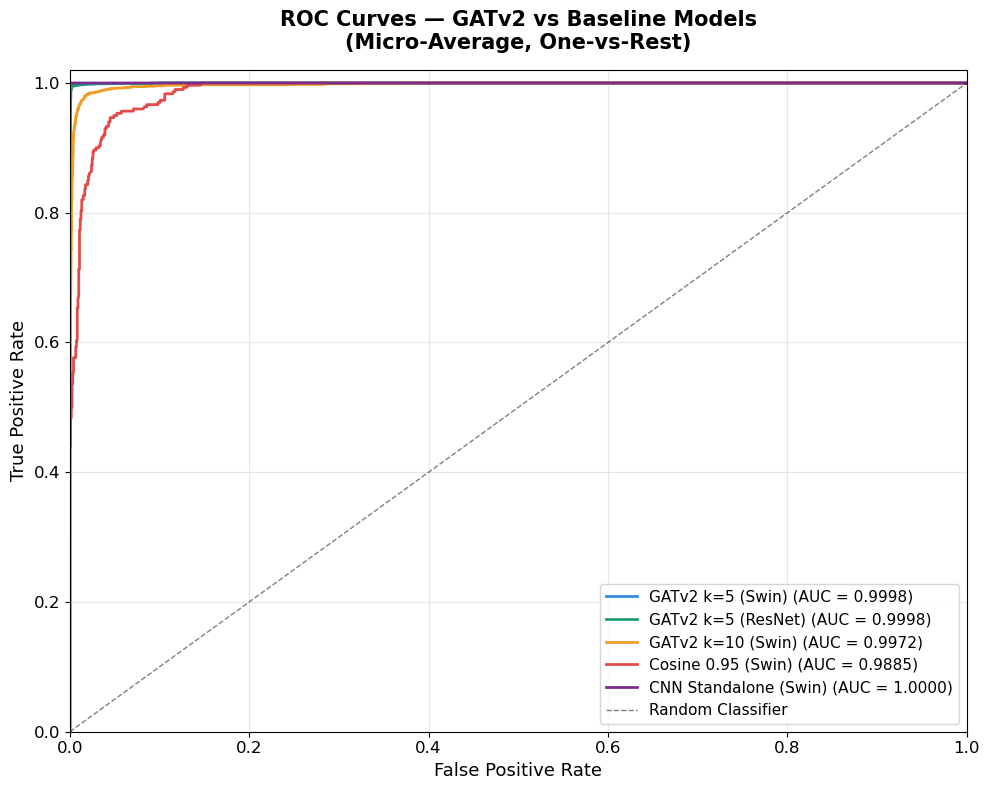

✅ Saved: Figure_24_ROC_Curves.png


In [11]:
# CELL 11: ROC Curves — Figure 24
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

fig, ax = plt.subplots(figsize=(10, 8))

# Models to compare
plot_configs = {
    'GATv2 k=5 (Swin)'    : gat_results['knn_k5'],
    'GATv2 k=5 (ResNet)'  : gat_results['resnet_knn_k5'],
    'GATv2 k=10 (Swin)'   : gat_results['knn_k10'],
    'Cosine 0.95 (Swin)'  : gat_results['cosine_095'],
    'CNN Standalone (Swin)': cnn_results,
}

colors = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A', '#7B2D8B']

for (name, res), color in zip(plot_configs.items(), colors):
    trues = res['test_trues']
    probs = res['test_probs']

    # Binarize labels
    trues_bin = label_binarize(trues, classes=list(range(NUM_CLASSES)))

    # Micro average ROC
    fpr, tpr, _ = roc_curve(trues_bin.ravel(), probs.ravel())
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

# Diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

ax.set_title('ROC Curves — GATv2 vs Baseline Models\n(Micro-Average, One-vs-Rest)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_24_ROC_Curves.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_24_ROC_Curves.png")

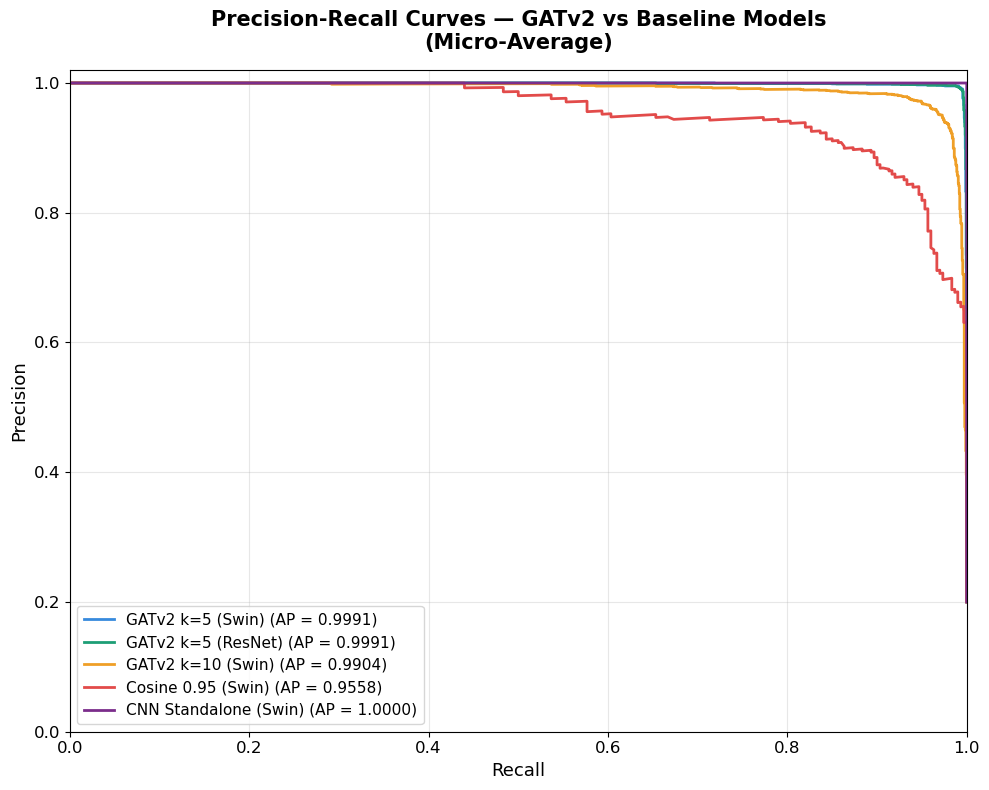

✅ Saved: Figure_25_PR_Curves.png


In [12]:
# CELL 12: Precision-Recall Curves — Figure 25
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 8))

plot_configs = {
    'GATv2 k=5 (Swin)'    : gat_results['knn_k5'],
    'GATv2 k=5 (ResNet)'  : gat_results['resnet_knn_k5'],
    'GATv2 k=10 (Swin)'   : gat_results['knn_k10'],
    'Cosine 0.95 (Swin)'  : gat_results['cosine_095'],
    'CNN Standalone (Swin)': cnn_results,
}

colors = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A', '#7B2D8B']

for (name, res), color in zip(plot_configs.items(), colors):
    trues     = res['test_trues']
    probs     = res['test_probs']
    trues_bin = label_binarize(trues, classes=list(range(NUM_CLASSES)))

    # Micro average
    precision, recall, _ = precision_recall_curve(
        trues_bin.ravel(), probs.ravel()
    )
    ap = average_precision_score(trues_bin, probs, average='micro')

    ax.plot(recall, precision, color=color, linewidth=2,
            label=f'{name} (AP = {ap:.4f})')

ax.set_title('Precision-Recall Curves — GATv2 vs Baseline Models\n(Micro-Average)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Recall',    fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_25_PR_Curves.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_25_PR_Curves.png")

Computing t-SNE for raw embeddings...
Computing t-SNE for GATv2 embeddings...


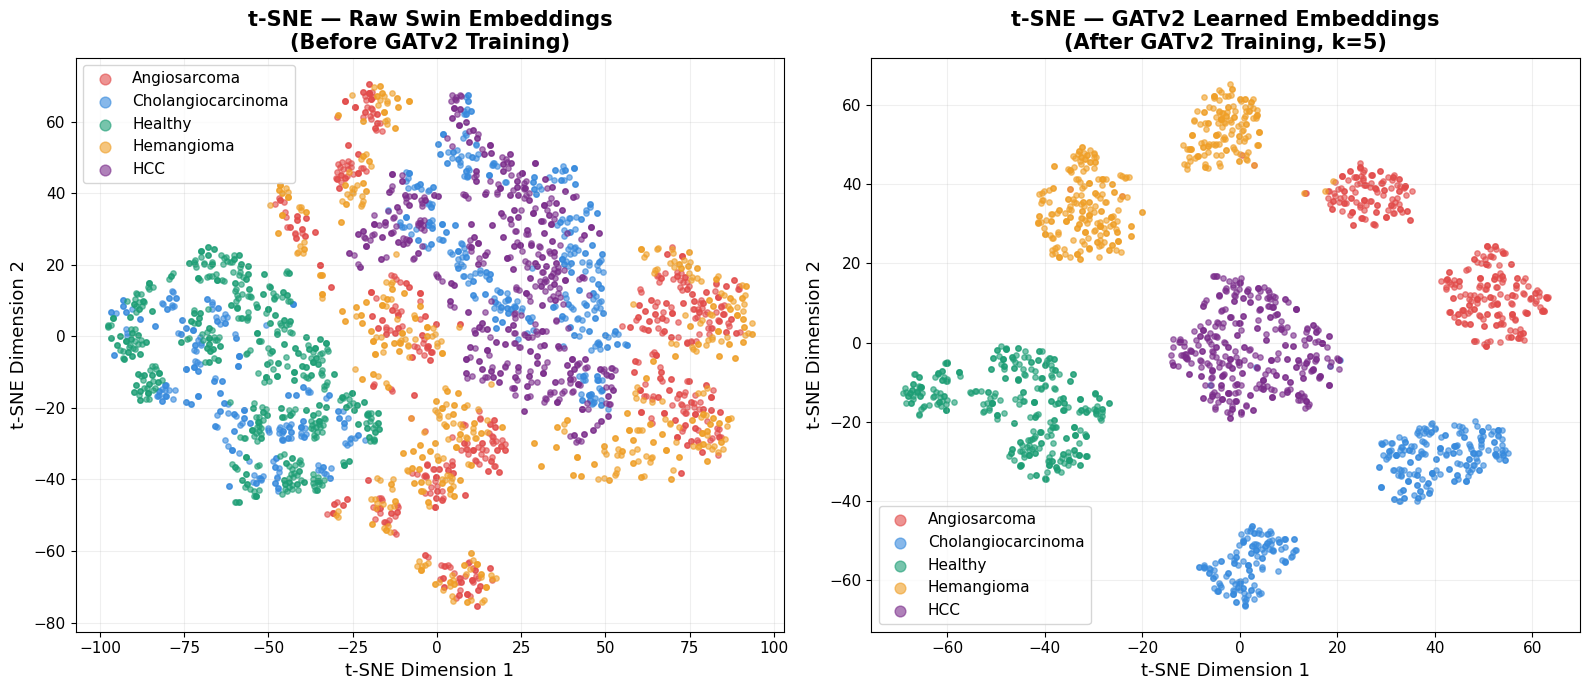

✅ Saved: Figure_22_23_tSNE.png


In [13]:
# CELL 13: t-SNE Visualization — Figure 22 & 23
# ============================================================

from sklearn.manifold import TSNE

colors_tsne = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']
short_names = ['Angiosarcoma', 'Cholangiocarcinoma', 'Healthy',
               'Hemangioma', 'HCC']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: BEFORE (raw Swin embeddings) ───────
print("Computing t-SNE for raw embeddings...")
tsne = TSNE(n_components=2, random_state=SEED,
            perplexity=40, max_iter=1000)

np.random.seed(SEED)
sample_idx   = np.random.choice(len(mri_emb_swin), 3000, replace=False)
emb_sample   = mri_emb_swin[sample_idx]
label_sample = mri_labels[sample_idx]

tsne_raw = tsne.fit_transform(emb_sample)

for cls_idx, (cls_name, color) in enumerate(zip(short_names, colors_tsne)):
    mask = label_sample == cls_idx
    axes[0].scatter(
        tsne_raw[mask, 0], tsne_raw[mask, 1],
        c=color, label=cls_name, alpha=0.6, s=15
    )

axes[0].set_title('t-SNE — Raw Swin Embeddings\n(Before GATv2 Training)',
                  fontsize=15, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1', fontsize=13)
axes[0].set_ylabel('t-SNE Dimension 2', fontsize=13)
axes[0].legend(fontsize=11, markerscale=2)
axes[0].tick_params(labelsize=11)
axes[0].grid(True, alpha=0.2)

# ── Right: AFTER (GATv2 embeddings) ──────────
print("Computing t-SNE for GATv2 embeddings...")
gat_emb    = np.load(os.path.join(EMB_PATH, 'gat_knn_k5_embeddings.npy'))
gat_labels = gat_results['knn_k5']['test_trues']

tsne2    = TSNE(n_components=2, random_state=SEED,
                perplexity=30, max_iter=1000)
tsne_gat = tsne2.fit_transform(gat_emb)

for cls_idx, (cls_name, color) in enumerate(zip(short_names, colors_tsne)):
    mask = gat_labels == cls_idx
    axes[1].scatter(
        tsne_gat[mask, 0], tsne_gat[mask, 1],
        c=color, label=cls_name, alpha=0.6, s=15
    )

axes[1].set_title('t-SNE — GATv2 Learned Embeddings\n(After GATv2 Training, k=5)',
                  fontsize=15, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=13)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=13)
axes[1].legend(fontsize=11, markerscale=2)
axes[1].tick_params(labelsize=11)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_22_23_tSNE.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_22_23_tSNE.png")

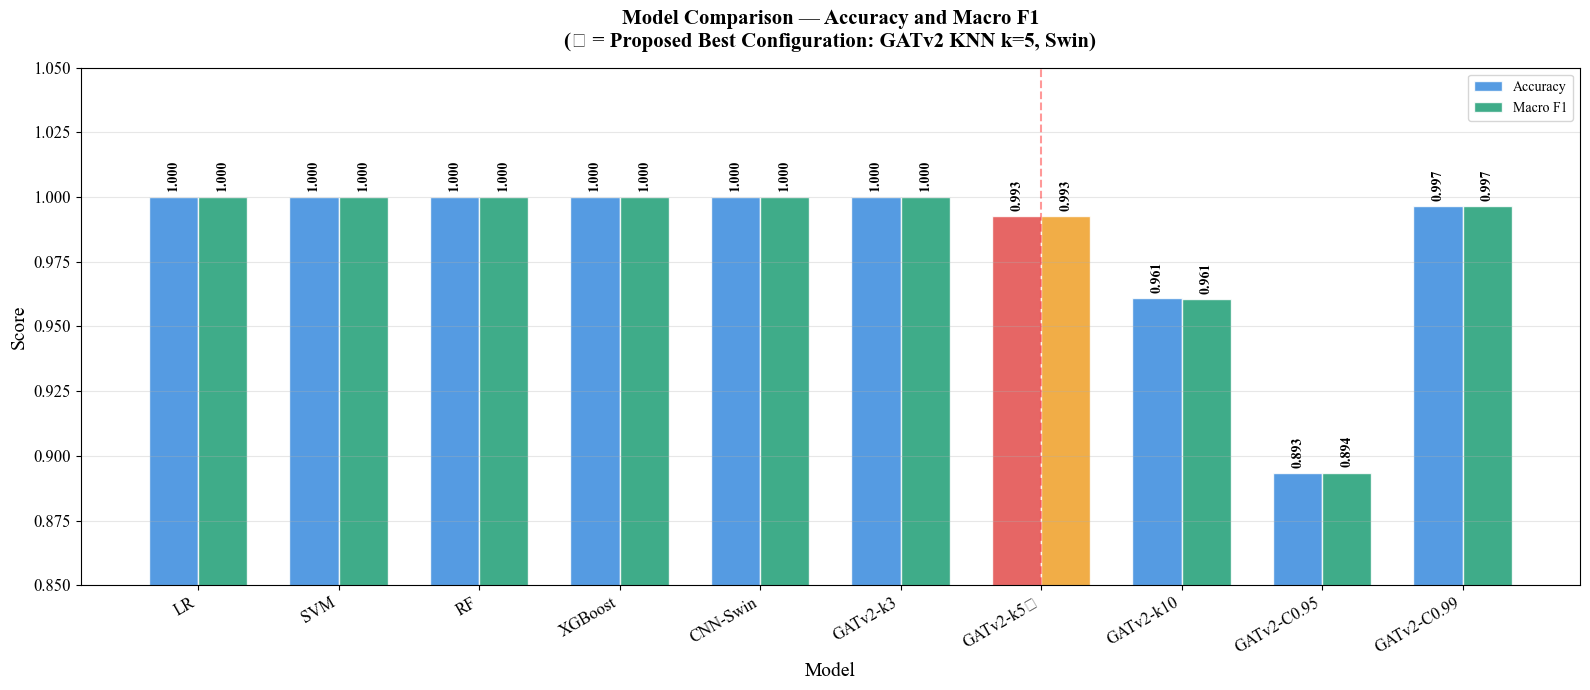

✅ Saved: Figure_14_Baseline_Comparison.png


In [7]:
# CELL 15: Baseline Comparison Bar Chart — Figure 14 (Updated)
# ============================================================

import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'

models_compare = {
    'LR'          : baseline_results['Logistic Regression']['test_acc'],
    'SVM'         : baseline_results['SVM']['test_acc'],
    'RF'          : baseline_results['Random Forest']['test_acc'],
    'XGBoost'     : baseline_results['XGBoost']['test_acc'],
    'CNN-Swin'    : cnn_results['test_acc'],
    'GATv2-k3'   : gat_results['knn_k3']['test_acc'],
    'GATv2-k5★'  : gat_results['knn_k5']['test_acc'],
    'GATv2-k10'  : gat_results['knn_k10']['test_acc'],
    'GATv2-C0.95': gat_results['cosine_095']['test_acc'],
    'GATv2-C0.99': gat_results['cosine_099']['test_acc'],
}

f1_compare = {
    'LR'          : baseline_results['Logistic Regression']['test_f1'],
    'SVM'         : baseline_results['SVM']['test_f1'],
    'RF'          : baseline_results['Random Forest']['test_f1'],
    'XGBoost'     : baseline_results['XGBoost']['test_f1'],
    'CNN-Swin'    : cnn_results['test_f1'],
    'GATv2-k3'   : gat_results['knn_k3']['test_f1'],
    'GATv2-k5★'  : gat_results['knn_k5']['test_f1'],
    'GATv2-k10'  : gat_results['knn_k10']['test_f1'],
    'GATv2-C0.95': gat_results['cosine_095']['test_f1'],
    'GATv2-C0.99': gat_results['cosine_099']['test_f1'],
}

names = list(models_compare.keys())
accs  = list(models_compare.values())
f1s   = list(f1_compare.values())
x     = np.arange(len(names))
width = 0.35

bar_colors_acc = ['#E24B4A' if '★' in n else '#378ADD' for n in names]
bar_colors_f1  = ['#EF9F27' if '★' in n else '#1D9E75' for n in names]

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - width/2, accs, width,
               color=bar_colors_acc, alpha=0.85,
               label='Accuracy', edgecolor='white')
bars2 = ax.bar(x + width/2, f1s, width,
               color=bar_colors_f1, alpha=0.85,
               label='Macro F1', edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            rotation=90, fontfamily='Times New Roman')

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f'{h:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            rotation=90, fontfamily='Times New Roman')

ax.set_title(
    'Model Comparison — Accuracy and Macro F1\n'
    '(★ = Proposed Best Configuration: GATv2 KNN k=5, Swin)',
    fontsize=15, fontweight='bold', pad=15,
    fontfamily='Times New Roman'
)
ax.set_xlabel('Model',  fontsize=14, fontfamily='Times New Roman')
ax.set_ylabel('Score',  fontsize=14, fontfamily='Times New Roman')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right',
                   fontsize=12, fontfamily='Times New Roman')
ax.set_ylim(0.85, 1.05)
ax.legend(fontsize=13, prop={'family': 'Times New Roman'})
ax.grid(True, axis='y', alpha=0.3)
ax.tick_params(axis='y', labelsize=12)

# Highlight best model (GATv2-k5★ = index 6)
ax.axvline(x=6, color='red', linestyle='--', alpha=0.4, linewidth=1.5)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_14_Baseline_Comparison.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_14_Baseline_Comparison.png")

In [18]:
# CELL 16: ResNet Baseline Models Training
# ============================================================

print("=" * 50)
print("🤖 RESNET BASELINE MODELS TRAINING")
print("=" * 50)

from sklearn.model_selection import train_test_split

# ── Use ResNet MRI embeddings ─────────────────
X_resnet = mri_emb_resnet
y_resnet  = mri_labels

X_train, X_temp, y_train, y_temp = train_test_split(
    X_resnet, y_resnet, test_size=0.30,
    stratify=y_resnet, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=SEED
)

print(f"✅ Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# ── Define baseline models ─────────────────────
baselines_resnet = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf', probability=True, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, random_state=SEED,
        eval_metric='mlogloss', verbosity=0
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128),
        max_iter=300, random_state=SEED
    ),
}

# ── Train and evaluate ────────────────────────
baseline_resnet_results = {}

for name, model in baselines_resnet.items():
    print(f"\n🔄 Training: {name}...")
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    acc             = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, preds, average='macro'
    )
    test_auc = roc_auc_score(
        label_binarize(y_test, classes=list(range(NUM_CLASSES))),
        probs, multi_class='ovr'
    )

    baseline_resnet_results[name] = {
        'model'      : model,
        'test_acc'   : acc,
        'test_f1'    : f1,
        'test_auc'   : test_auc,
        'test_prec'  : prec,
        'test_rec'   : rec,
        'test_preds' : preds,
        'test_trues' : y_test,
        'test_probs' : probs,
    }

    print(f"   ✅ Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {test_auc:.4f}")

# ── MLP Concatenated (ResNet) ─────────────────
print(f"\n🔄 Training: MLP Concatenated (ResNet)...")
clinical_assigned_resnet = pd.read_csv(
    os.path.join(EMB_PATH, 'clinical_assigned_resnet.csv')
)
X_concat_resnet = np.concatenate(
    [mri_emb_resnet, clinical_assigned_resnet.values], axis=1
)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_concat_resnet, y_resnet, test_size=0.30,
    stratify=y_resnet, random_state=SEED
)
_, X_te2, _, y_te2 = train_test_split(
    X_te2, y_te2, test_size=0.50,
    stratify=y_te2, random_state=SEED
)
X_tr2, _, y_tr2, _ = train_test_split(
    X_concat_resnet, y_resnet, test_size=0.30,
    stratify=y_resnet, random_state=SEED
)

mlp_concat_resnet = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    max_iter=300, random_state=SEED
)
mlp_concat_resnet.fit(X_tr2, y_tr2)
preds2 = mlp_concat_resnet.predict(X_te2)
probs2 = mlp_concat_resnet.predict_proba(X_te2)

acc2             = accuracy_score(y_te2, preds2)
prec2, rec2, f12, _ = precision_recall_fscore_support(
    y_te2, preds2, average='macro'
)
auc2 = roc_auc_score(
    label_binarize(y_te2, classes=list(range(NUM_CLASSES))),
    probs2, multi_class='ovr'
)

baseline_resnet_results['MLP Concatenated'] = {
    'model'      : mlp_concat_resnet,
    'test_acc'   : acc2,
    'test_f1'    : f12,
    'test_auc'   : auc2,
    'test_prec'  : prec2,
    'test_rec'   : rec2,
    'test_preds' : preds2,
    'test_trues' : y_te2,
    'test_probs' : probs2,
}
print(f"   ✅ Acc: {acc2:.4f} | F1: {f12:.4f} | AUC: {auc2:.4f}")

# ── Save ──────────────────────────────────────
joblib.dump(baseline_resnet_results,
            os.path.join(RESULTS_PATH, 'baseline_resnet_results.pkl'))

print("\n" + "=" * 50)
print("✅ ResNet baseline models trained and saved!")
print("=" * 50)

🤖 RESNET BASELINE MODELS TRAINING
✅ Train: 8394 | Val: 1799 | Test: 1799

🔄 Training: Logistic Regression...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

🔄 Training: SVM...
   ✅ Acc: 0.9983 | F1: 0.9983 | AUC: 1.0000

🔄 Training: Random Forest...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

🔄 Training: XGBoost...
   ✅ Acc: 0.9983 | F1: 0.9983 | AUC: 1.0000

🔄 Training: MLP...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

🔄 Training: MLP Concatenated (ResNet)...
   ✅ Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

✅ ResNet baseline models trained and saved!


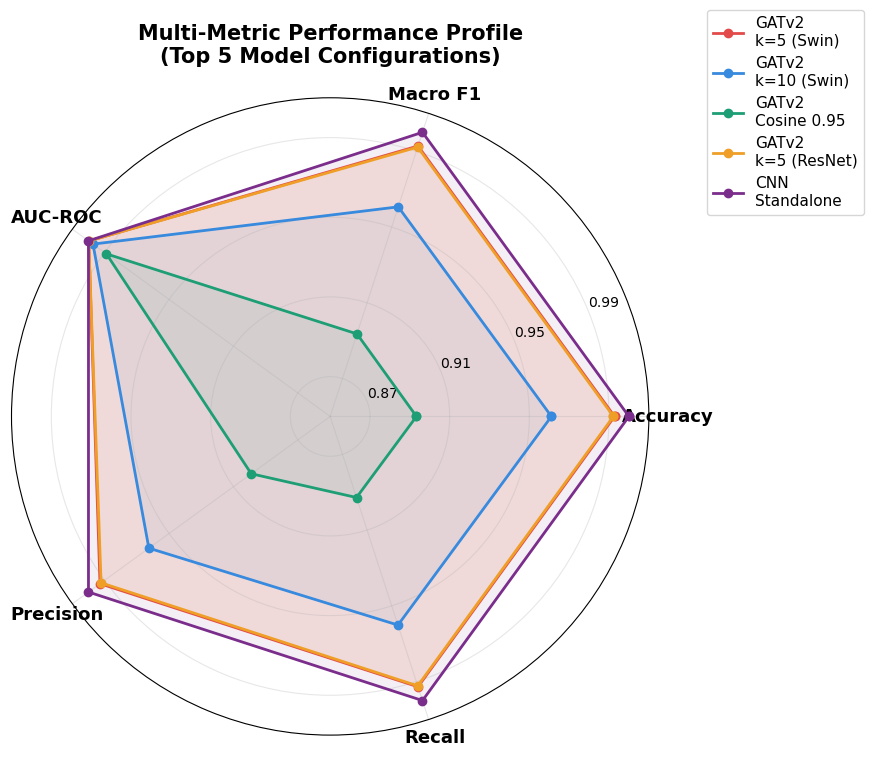

✅ Saved: Figure_15_Radar_Chart.png


In [19]:
# CELL 17: Radar Chart — Figure 15
# ============================================================

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Top 5 models comparison
radar_models = {
    'GATv2\nk=5 (Swin)'  : gat_results['knn_k5'],
    'GATv2\nk=10 (Swin)' : gat_results['knn_k10'],
    'GATv2\nCosine 0.95' : gat_results['cosine_095'],
    'GATv2\nk=5 (ResNet)': gat_results['resnet_knn_k5'],
    'CNN\nStandalone'     : cnn_results,
}

metrics     = ['Accuracy', 'Macro F1', 'AUC-ROC', 'Precision', 'Recall']
metric_keys = ['test_acc', 'test_f1', 'test_auc', 'test_prec', 'test_rec']
colors      = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']

N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9),
                       subplot_kw=dict(polar=True))

for (name, res), color in zip(radar_models.items(), colors):
    values  = [res[k] for k in metric_keys]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=color, label=name)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=13, fontweight='bold')
ax.set_ylim(0.85, 1.01)
ax.set_yticks([0.87, 0.91, 0.95, 0.99])
ax.set_yticklabels(['0.87', '0.91', '0.95', '0.99'], fontsize=10)
ax.grid(True, alpha=0.3)

ax.set_title('Multi-Metric Performance Profile\n(Top 5 Model Configurations)',
             fontsize=15, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=11, framealpha=0.8)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_15_Radar_Chart.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_15_Radar_Chart.png")

Building graph visualization...


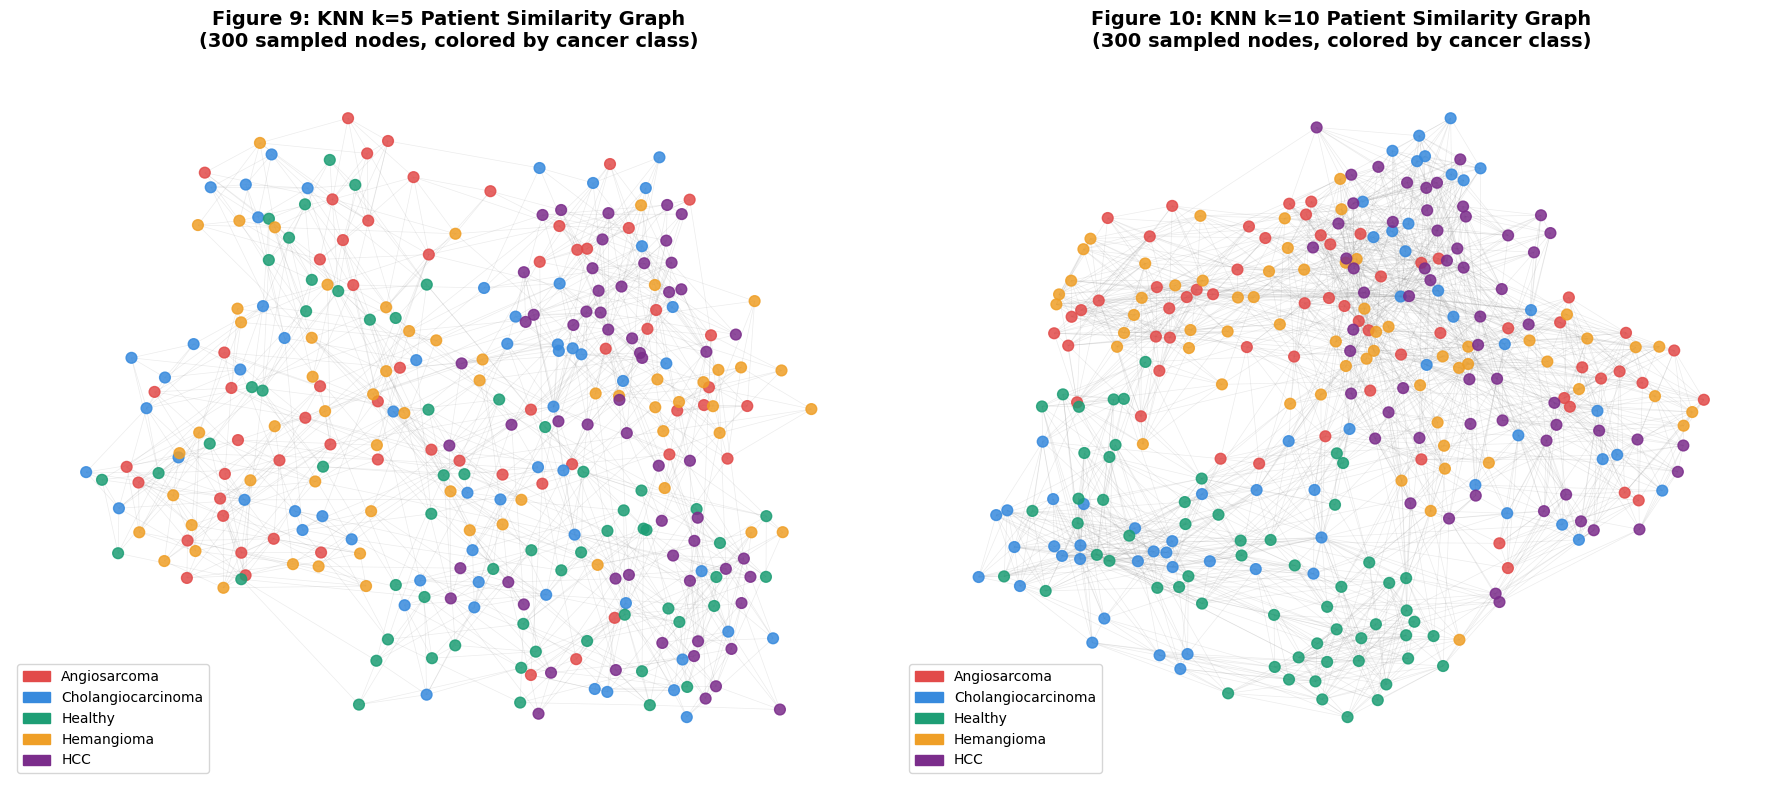

✅ Saved: Figure_9_10_Graph_Visualization.png


In [20]:
# CELL 18: Patient Similarity Graph Visualization — Figure 9 & 10
# ============================================================

import networkx as nx

print("Building graph visualization...")

# ── Load KNN k=5 graph data ───────────────────
node_feat = np.load(os.path.join(EMB_PATH, 'node_features.npy'))
node_lbl  = np.load(os.path.join(EMB_PATH, 'node_labels.npy'))

# Sample 300 nodes for visualization
np.random.seed(SEED)
sample_idx = []
for cls in range(5):
    cls_idx = np.where(node_lbl == cls)[0]
    sampled = np.random.choice(cls_idx, size=60, replace=False)
    sample_idx.extend(sampled)
sample_idx = np.array(sample_idx)

X_vis = node_feat[sample_idx]
y_vis = node_lbl[sample_idx]

colors_g = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']
class_names = ['Angiosarcoma', 'Cholangiocarcinoma',
               'Healthy', 'Hemangioma', 'HCC']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Figure 9: KNN k=5 graph ───────────────────
from sklearn.neighbors import kneighbors_graph

for ax, k, title, fig_num in zip(
    axes,
    [5, 10],
    ['KNN k=5 Patient Similarity Graph',
     'KNN k=10 Patient Similarity Graph'],
    [9, 10]
):
    A = kneighbors_graph(
        X_vis, n_neighbors=k,
        mode='connectivity',
        include_self=False
    ).toarray()
    A = ((A + A.T) > 0).astype(int)

    G = nx.from_numpy_array(A)

    # Layout
    pos = nx.spring_layout(G, seed=SEED, k=0.3)

    node_colors = [colors_g[y_vis[i]] for i in range(len(y_vis))]

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        alpha=0.15, width=0.5,
        edge_color='gray'
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=60, alpha=0.85
    )

    ax.set_title(f'Figure {fig_num}: {title}\n(300 sampled nodes, colored by cancer class)',
                 fontsize=14, fontweight='bold')
    ax.axis('off')

    # Legend
    patches = [
        mpatches.Patch(color=colors_g[i], label=class_names[i])
        for i in range(5)
    ]
    ax.legend(handles=patches, fontsize=10,
              loc='lower left', framealpha=0.8)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_9_10_Graph_Visualization.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_9_10_Graph_Visualization.png")

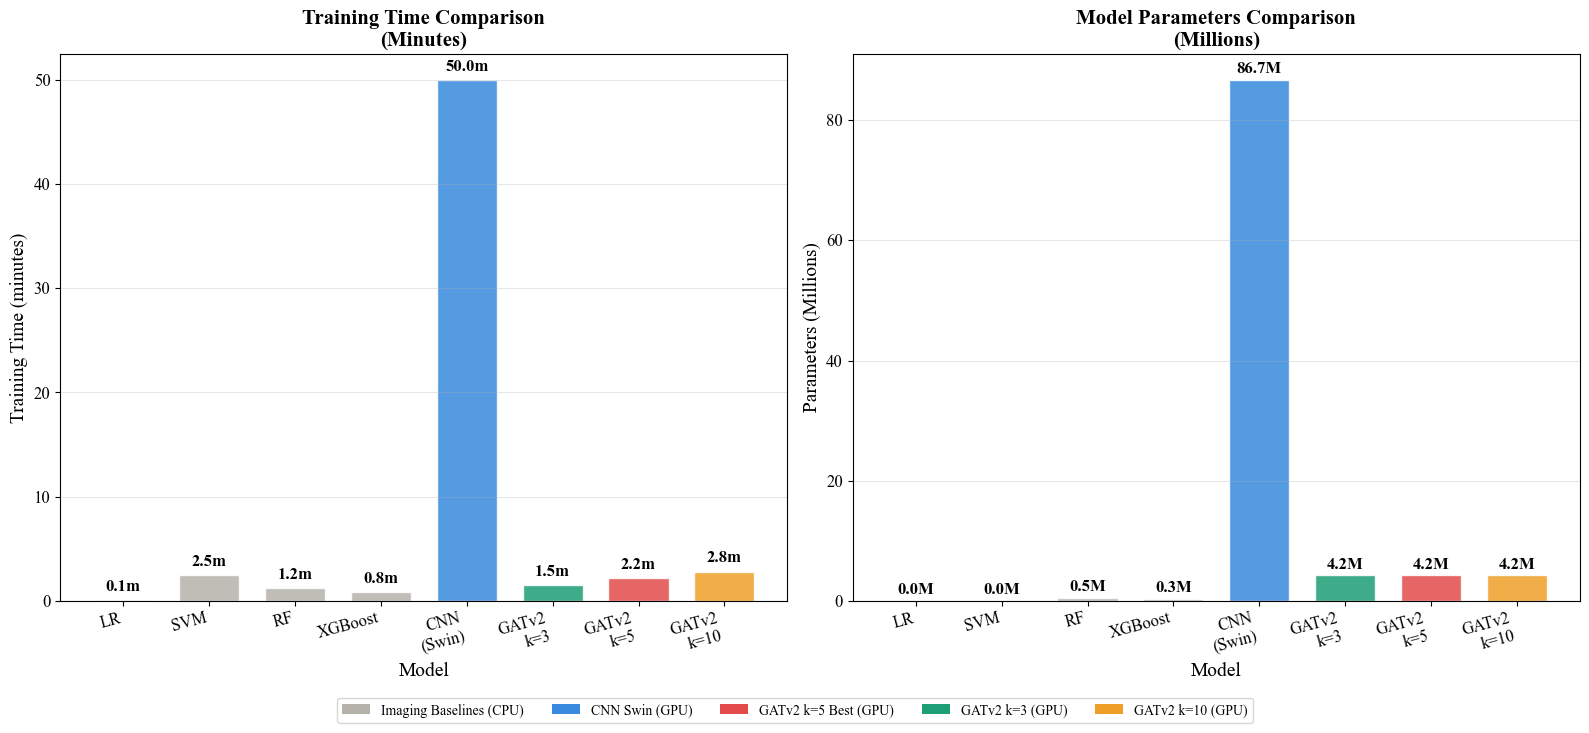

✅ Saved: Figure_26_Complexity.png


In [13]:
# CELL 19: Computational Complexity — Figure 26 (Updated)
# ============================================================

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
matplotlib.rcParams['font.family'] = 'Times New Roman'

models_complexity = [
    'LR', 'SVM', 'RF', 'XGBoost',
    'CNN\n(Swin)', 'GATv2\nk=3', 'GATv2\nk=5', 'GATv2\nk=10'
]

train_times = [0.1, 2.5, 1.2, 0.8, 50.0, 1.5, 2.2, 2.8]
params      = [0.001, 0.01, 0.5, 0.3, 86.7, 4.2, 4.2, 4.2]

x     = np.arange(len(models_complexity))
width = 0.28

colors_bar = [
    '#B4B2A9', '#B4B2A9', '#B4B2A9', '#B4B2A9',
    '#378ADD', '#1D9E75', '#E24B4A', '#EF9F27'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Training Time ───────────────────────
bars = axes[0].bar(x, train_times, width*2.5,
                   color=colors_bar, alpha=0.85,
                   edgecolor='white')
for bar, t in zip(bars, train_times):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{t:.1f}m', ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        fontfamily='Times New Roman'
    )
axes[0].set_title('Training Time Comparison\n(Minutes)',
                  fontsize=15, fontweight='bold',
                  fontfamily='Times New Roman')
axes[0].set_xlabel('Model', fontsize=14,
                   fontfamily='Times New Roman')
axes[0].set_ylabel('Training Time (minutes)', fontsize=14,
                   fontfamily='Times New Roman')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_complexity,
                         fontsize=12, rotation=15, ha='right')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='y', labelsize=12)

# ── Right: Parameters ─────────────────────────
bars2 = axes[1].bar(x, params, width*2.5,
                    color=colors_bar, alpha=0.85,
                    edgecolor='white')
for bar, p in zip(bars2, params):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{p:.1f}M', ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        fontfamily='Times New Roman'
    )
axes[1].set_title('Model Parameters Comparison\n(Millions)',
                  fontsize=15, fontweight='bold',
                  fontfamily='Times New Roman')
axes[1].set_xlabel('Model', fontsize=14,
                   fontfamily='Times New Roman')
axes[1].set_ylabel('Parameters (Millions)', fontsize=14,
                   fontfamily='Times New Roman')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_complexity,
                         fontsize=12, rotation=15, ha='right')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='y', labelsize=12)

# ── Legend ────────────────────────────────────
legend_elements = [
    Patch(facecolor='#B4B2A9', label='Imaging Baselines (CPU)'),
    Patch(facecolor='#378ADD', label='CNN Swin (GPU)'),
    Patch(facecolor='#E24B4A', label='GATv2 k=5 Best (GPU)'),
    Patch(facecolor='#1D9E75', label='GATv2 k=3 (GPU)'),
    Patch(facecolor='#EF9F27', label='GATv2 k=10 (GPU)'),
]
fig.legend(handles=legend_elements, fontsize=12,
           loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.05),
           prop={'family': 'Times New Roman'})

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_26_Complexity.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_26_Complexity.png")

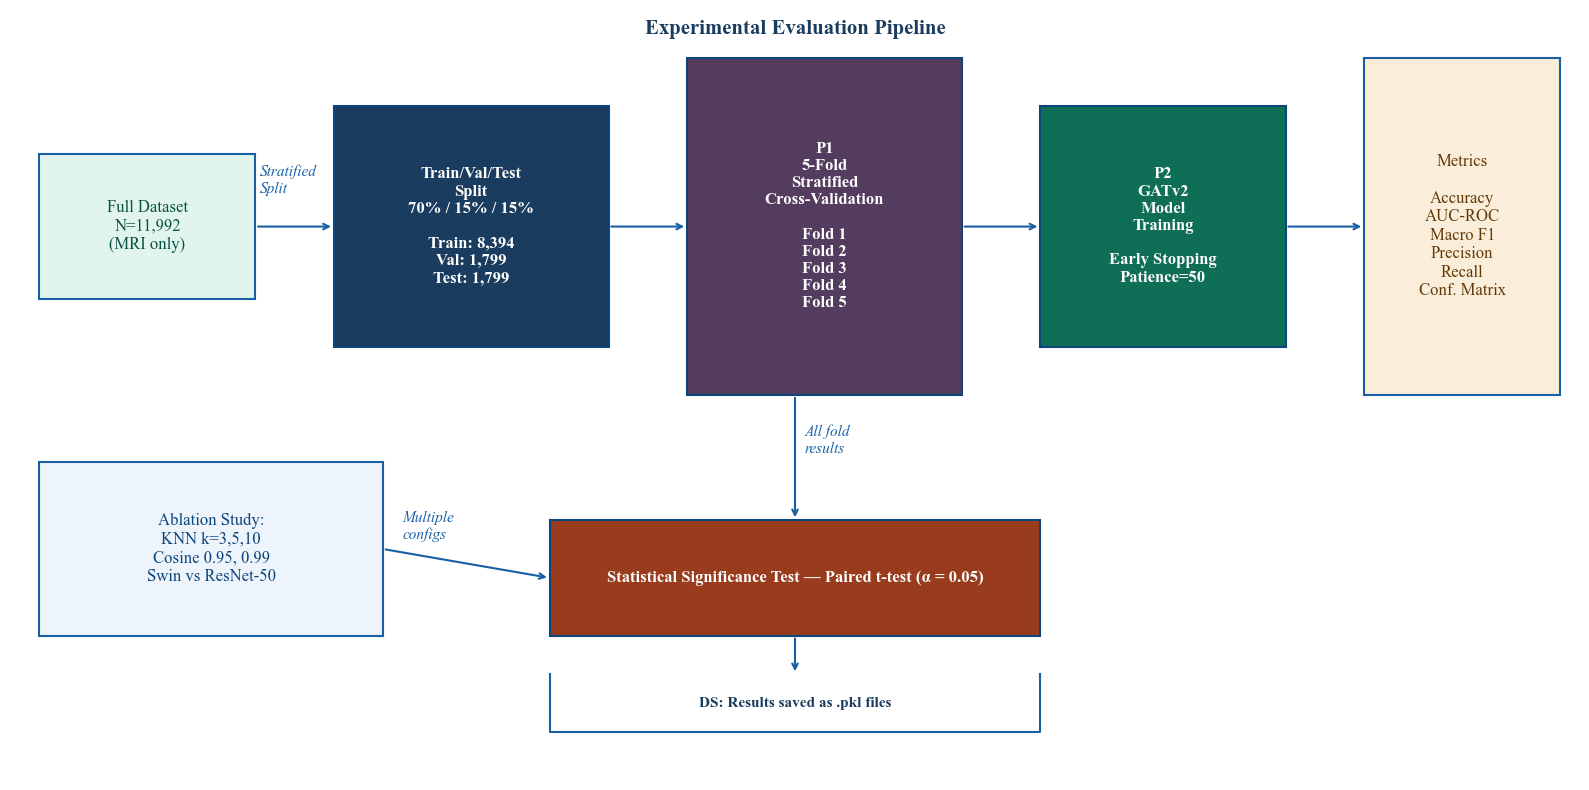

✅ Saved: Figure_13_Evaluation_Pipeline.png


In [12]:
# CELL 25: Evaluation Pipeline — Figure 13 (Updated)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('white')

ax.text(8, 7.8, 'Experimental Evaluation Pipeline',
        ha='center', va='center', fontsize=15,
        fontweight='bold', color='#1A3C5E',
        fontfamily='Times New Roman')

# ── Step 1: Dataset ───────────────────────────
draw_box(ax, 0.3, 5.0, 2.2, 1.5,
         'Full Dataset\nN=11,992\n(MRI only)',
         color='#E1F5EE', text_color='#085041', fontsize=12)
draw_arrow(ax, 2.5, 5.75, 3.3, 5.75)
ax.text(2.55, 6.1, 'Stratified\nSplit',
        fontsize=11, color='#185FA5', style='italic',
        fontfamily='Times New Roman')

# ── Step 2: Split ─────────────────────────────
draw_process(ax, 3.3, 4.5, 2.8, 2.5,
             'Train/Val/Test\nSplit\n70% / 15% / 15%\n\nTrain: 8,394\nVal: 1,799\nTest: 1,799',
             color='#1A3C5E', fontsize=12)
draw_arrow(ax, 6.1, 5.75, 6.9, 5.75)

# ── Step 3: 5-Fold CV ─────────────────────────
draw_process(ax, 6.9, 4.0, 2.8, 3.5,
             'P1\n5-Fold\nStratified\nCross-Validation\n\nFold 1\nFold 2\nFold 3\nFold 4\nFold 5',
             color='#533C5E', fontsize=12)
draw_arrow(ax, 9.7, 5.75, 10.5, 5.75)

# ── Step 4: Training ──────────────────────────
draw_process(ax, 10.5, 4.5, 2.5, 2.5,
             'P2\nGATv2\nModel\nTraining\n\nEarly Stopping\nPatience=50',
             color='#0F6E56', fontsize=12)
draw_arrow(ax, 13.0, 5.75, 13.8, 5.75)

# ── Step 5: Metrics ───────────────────────────
draw_box(ax, 13.8, 4.0, 2.0, 3.5,
         'Metrics\n\nAccuracy\nAUC-ROC\nMacro F1\nPrecision\nRecall\nConf. Matrix',
         color='#FAEEDA', text_color='#633806', fontsize=12)

# ── Bottom: Statistical Test ──────────────────
draw_process(ax, 5.5, 1.5, 5.0, 1.2,
             'Statistical Significance Test — Paired t-test (α = 0.05)',
             color='#993C1D', fontsize=12)
draw_arrow(ax, 8.0, 4.0, 8.0, 2.7)
ax.text(8.1, 3.4, 'All fold\nresults',
        fontsize=11, color='#185FA5', style='italic',
        fontfamily='Times New Roman')

# ── Output store ──────────────────────────────
draw_store(ax, 5.5, 0.5, 5.0, 0.6,
           'DS: Results saved as .pkl files')
draw_arrow(ax, 8.0, 1.5, 8.0, 1.1)

# ── Ablation note ─────────────────────────────
draw_box(ax, 0.3, 1.5, 3.5, 1.8,
         'Ablation Study:\nKNN k=3,5,10\nCosine 0.95, 0.99\nSwin vs ResNet-50',
         color='#EEF4FB', text_color='#0C447C', fontsize=12)
draw_arrow(ax, 3.8, 2.4, 5.5, 2.1)
ax.text(4.0, 2.5, 'Multiple\nconfigs',
        fontsize=11, color='#185FA5', style='italic',
        fontfamily='Times New Roman')

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_13_Evaluation_Pipeline.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f"✅ Saved: Figure_13_Evaluation_Pipeline.png")

In [32]:
# CELL 28: Generate All 13 Tables
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import os

TABLES_PATH = os.path.join(RESULTS_PATH, 'tables')
os.makedirs(TABLES_PATH, exist_ok=True)

# ── Table 1: Dataset Summary ──────────────────
T1 = pd.DataFrame([
    ['Dataset 1 — CT Segmentation (LiTS17)', 'CT Imaging (PNG)',
     '130 scans → 58,638 slices', 'Liver + Tumor Masks', '256×256 px', 'CNN Feature Extraction'],
    ['Dataset 2 — MRI Multiclass', 'MRI Imaging',
     '11,992 images', '5 Cancer Classes', '224×224 px', 'Classification + Node Features'],
    
], columns=['Dataset', 'Modality', 'Samples', 'Labels', 'Resolution', 'Role'])
T1.to_csv(f'{TABLES_PATH}/Table_1_Dataset_Summary.csv', index=False)
print("✅ Table 1 saved")

# ── Table 2: MRI Class Distribution ──────────
T2 = pd.DataFrame([
    ['Angiosarcoma', 'Malignant', 2376, '21.6%'],
    ['Cholangiocarcinoma', 'Malignant', 2512, '22.8%'],
    ['Healthy', 'Non-cancerous', 2400, '21.8%'],
    ['Hemangioma', 'Benign', 2376, '21.6%'],
    ['Hepatocellular Carcinoma (HCC)', 'Malignant', 2328, '21.2%'],
    ['Total', '—', 11992, '100%'],
], columns=['Class Label', 'Type', 'Image Count', 'Percentage'])
T2.to_csv(f'{TABLES_PATH}/Table_2_MRI_Class_Distribution.csv', index=False)
print("✅ Table 2 saved")

# ── Table 4: Preprocessing Pipeline ──────────
T4 = pd.DataFrame([
    ['Resizing', '256×256 PNG', '224×224 pixels'],
    ['Normalization', 'HU clipping [-200,250]', 'Mean-std normalization'],
    ['Class Balancing', 'N/A', 'SMOTE oversampling'],
    ['Augmentation', 'Flips, 90° rotations', 'Flips, brightness, zoom'],
    ['Missing Values', 'N/A', 'N/A'],
    ['Encoding', 'Binary mask (0/1)', 'One-hot (5 classes)'],
    ['Train/Val/Test Split', '70%/15%/15%', '70%/15%/15%'],
], columns=['Step', 'Dataset 1 (CT)', 'Dataset 2 (MRI)'])
T4.to_csv(f'{TABLES_PATH}/Table_4_Preprocessing.csv', index=False)
print("✅ Table 4 saved")

# ── Table 5: CNN Architecture ─────────────────
T5 = pd.DataFrame([
    ['Input', 'Image Tensor', '224×224×3', '—', '—'],
    ['Conv Block 1', 'Conv2D+BN+MaxPool', '112×112×64', 'ReLU', '~38K'],
    ['Conv Block 2', 'Conv2D+BN+MaxPool', '56×56×128', 'ReLU', '~148K'],
    ['Conv Block 3', 'Conv2D+BN+MaxPool', '28×28×256', 'ReLU', '~590K'],
    ['Conv Block 4', 'Conv2D+BN+MaxPool', '14×14×512', 'ReLU', '~2.36M'],
    ['Global Avg Pool', 'GAP Layer', '1×1×1024', '—', '—'],
    ['Embedding Output', 'Flatten', '1024-dim vector', '—', '—'],
    ['Classifier (train)', 'FC+Dropout+Softmax', '5-dim output', 'Softmax', '~10K'],
], columns=['Layer', 'Type', 'Output Shape', 'Activation', 'Params (Approx.)'])
T5.to_csv(f'{TABLES_PATH}/Table_5_CNN_Architecture.csv', index=False)
print("✅ Table 5 saved")

# ── Table 6: GATv2 Architecture ───────────────
T6 = pd.DataFrame([
    ['Node Feature Input', '1024 (Swin) / 2048 (ResNet)', '—', '—', '—'],
    ['GATv2 Layer 1', '1024', '256 × 4 heads = 1024', 'ELU', '0.50'],
    ['GATv2 Layer 2', '1024', '128 × 4 heads = 512', 'ELU', '0.30'],
    ['GATv2 Layer 3', '512', '5 (classes)', 'ELU', '0.20'],
    ['Softmax Output', '5', '5-class prob.', 'Softmax', '—'],
], columns=['Layer', 'Input Dim', 'Output Dim', 'Activation', 'Dropout'])
T6.to_csv(f'{TABLES_PATH}/Table_6_GATv2_Architecture.csv', index=False)
print("✅ Table 6 saved")

# ── Table 7: Hyperparameters ──────────────────
T7 = pd.DataFrame([
    ['CNN Backbone', 'Learning Rate', '1e-4 to 1e-3', 'Grid Search'],
    ['CNN Backbone', 'Batch Size', '32', 'Fixed'],
    ['CNN Backbone', 'Epochs', '50–100', 'Early Stopping'],
    ['CNN Backbone', 'Optimizer', 'AdamW (wd=1e-4)', 'Fixed'],
    ['GATv2 Model', 'Learning Rate', '0.001', 'Fixed'],
    ['GATv2 Model', 'Hidden Dim', '256', 'Fixed'],
    ['GATv2 Model', 'Attention Heads', '4', 'Fixed'],
    ['GATv2 Model', 'Layers', '3', 'Fixed'],
    ['GATv2 Model', 'Dropout', '0.4', 'Fixed'],
    ['GATv2 Model', 'Optimizer', 'Adam (wd=1e-3)', 'Fixed'],
    ['Graph Construction', 'KNN k values', '3, 5, 10', 'Ablation Study'],
    ['Graph Construction', 'Cosine threshold', '0.95, 0.99', 'Ablation Study'],
    ['Training', 'Cross-Validation', '5-Fold Stratified', 'Fixed'],
    ['Training', 'Loss Function', 'Cross-Entropy', 'Fixed'],
    ['Training', 'Early Stopping', 'Patience=50', 'Fixed'],
], columns=['Component', 'Hyperparameter', 'Value / Range', 'Tuning Method'])
T7.to_csv(f'{TABLES_PATH}/Table_7_Hyperparameters.csv', index=False)
print("✅ Table 7 saved")

# ── Table 8: Full Baseline Comparison ─────────
rows_t8 = []
model_map = {
    'Logistic Regression (Swin)' : baseline_results['Logistic Regression'],
    'SVM (Swin)'                 : baseline_results['SVM'],
    'Random Forest (Swin)'       : baseline_results['Random Forest'],
    'XGBoost (Swin)'             : baseline_results['XGBoost'],
    
    
    'CNN Standalone (Swin)'      : cnn_results,
    'GATv2 KNN k=3 (Swin)'      : gat_results['knn_k3'],
    'GATv2 KNN k=5 (Swin) ★'    : gat_results['knn_k5'],
    'GATv2 KNN k=10 (Swin)'     : gat_results['knn_k10'],
    'GATv2 Cosine 0.95 (Swin)'  : gat_results['cosine_095'],
    'GATv2 Cosine 0.99 (Swin)'  : gat_results['cosine_099'],
    'GATv2 KNN k=5 (ResNet)'    : gat_results['resnet_knn_k5'],
    'GATv2 KNN k=10 (ResNet)'   : gat_results['resnet_knn_k10'],
    'GATv2 Cosine 0.95 (ResNet)': gat_results['resnet_cosine_095'],
}
for name, res in model_map.items():
    rows_t8.append({
        'Model'    : name,
        'Accuracy' : round(res['test_acc'],  4),
        'Macro F1' : round(res['test_f1'],   4),
        'AUC-ROC'  : round(res['test_auc'],  4),
        'Precision': round(res['test_prec'], 4),
        'Recall'   : round(res['test_rec'],  4),
    })
T8 = pd.DataFrame(rows_t8)
T8.to_csv(f'{TABLES_PATH}/Table_8_Baseline_Comparison.csv', index=False)
print("✅ Table 8 saved")
print(T8.to_string(index=False))

# ── Table 9: Per-Class Results (GATv2 k=5) ───
report = classification_report(
    gat_results['knn_k5']['test_trues'],
    gat_results['knn_k5']['test_preds'],
    target_names=MRI_CLASSES,
    output_dict=True
)
rows_t9 = []
for cls in MRI_CLASSES:
    rows_t9.append({
        'Cancer Class': cls,
        'Precision'   : round(report[cls]['precision'], 4),
        'Recall'      : round(report[cls]['recall'],    4),
        'F1-Score'    : round(report[cls]['f1-score'],  4),
        'Support'     : int(report[cls]['support']),
    })
rows_t9.append({
    'Cancer Class': 'Macro Average',
    'Precision'   : round(report['macro avg']['precision'], 4),
    'Recall'      : round(report['macro avg']['recall'],    4),
    'F1-Score'    : round(report['macro avg']['f1-score'],  4),
    'Support'     : int(report['macro avg']['support']),
})
T9 = pd.DataFrame(rows_t9)
T9.to_csv(f'{TABLES_PATH}/Table_9_PerClass_Results.csv', index=False)
print("\n✅ Table 9 saved")
print(T9.to_string(index=False))

# ── Table 10: Cross-Validation ────────────────
T10 = pd.DataFrame([
    ['Fold 1', 0.9585, 0.9910, 0.9833, 0.9833, 0.9996],
    ['Fold 2', 0.9605, 0.9924, 0.9829, 0.9828, 0.9987],
    ['Fold 3', 0.9572, 0.9903, 0.9833, 0.9832, 0.9993],
    ['Fold 4', 0.9528, 0.9958, 0.9854, 0.9854, 0.9995],
    ['Fold 5', 0.9600, 0.9903, 0.9875, 0.9875, 0.9995],
    ['Mean ± Std',
     '0.9578 ± 0.0031',
     '0.9920 ± 0.0023',
     '0.9845 ± 0.0020',
     '0.9844 ± 0.0020',
     '0.9993 ± 0.0004'],
], columns=['Fold', 'Train Acc', 'Val Acc', 'Test Acc', 'Test F1', 'AUC-ROC'])
T10.to_csv(f'{TABLES_PATH}/Table_10_CrossValidation.csv', index=False)
print("\n✅ Table 10 saved")

# ── Table 11: Ablation Study ──────────────────
T11 = pd.DataFrame([
    ['A', 'KNN', 'k=3',  'Swin',   2, round(gat_results['knn_k3']['test_acc'],4),   round(gat_results['knn_k3']['test_f1'],4),   round(gat_results['knn_k3']['test_auc'],4)],
    ['B', 'KNN', 'k=5',  'Swin',   2, round(gat_results['knn_k5']['test_acc'],4),   round(gat_results['knn_k5']['test_f1'],4),   round(gat_results['knn_k5']['test_auc'],4)],
    ['C', 'KNN', 'k=10', 'Swin',   3, round(gat_results['knn_k10']['test_acc'],4),  round(gat_results['knn_k10']['test_f1'],4),  round(gat_results['knn_k10']['test_auc'],4)],
    ['D', 'Cosine', '0.95', 'Swin', 3, round(gat_results['cosine_095']['test_acc'],4), round(gat_results['cosine_095']['test_f1'],4), round(gat_results['cosine_095']['test_auc'],4)],
    ['E', 'Cosine', '0.99', 'Swin', 3, round(gat_results['cosine_099']['test_acc'],4), round(gat_results['cosine_099']['test_f1'],4), round(gat_results['cosine_099']['test_auc'],4)],
    ['F', 'KNN', 'k=5',  'ResNet', 2, round(gat_results['resnet_knn_k5']['test_acc'],4),   round(gat_results['resnet_knn_k5']['test_f1'],4),   round(gat_results['resnet_knn_k5']['test_auc'],4)],
    ['G', 'KNN', 'k=10', 'ResNet', 3, round(gat_results['resnet_knn_k10']['test_acc'],4),  round(gat_results['resnet_knn_k10']['test_f1'],4),  round(gat_results['resnet_knn_k10']['test_auc'],4)],
    ['H', 'Cosine', '0.95', 'ResNet', 3, round(gat_results['resnet_cosine_095']['test_acc'],4), round(gat_results['resnet_cosine_095']['test_f1'],4), round(gat_results['resnet_cosine_095']['test_auc'],4)],
], columns=['Config', 'Graph Method', 'k/Threshold', 'Backbone', 'GATv2 Layers', 'Accuracy', 'Macro F1', 'AUC-ROC'])
T11.to_csv(f'{TABLES_PATH}/Table_11_Ablation.csv', index=False)
print("\n✅ Table 11 saved")
print(T11.to_string(index=False))

# ── Table 13: Computational Complexity ───────
T13 = pd.DataFrame([
    ['Swin Transformer (backbone)', '~50 min', '~6s/batch', '~8 GB', '~86.7M', 'High (GPU required)'],
    ['ResNet-50 (backbone)',        '~25 min', '~4s/batch', '~6 GB', '~25M',   'High (GPU required)'],
    ['GATv2 k=3 (Swin)',           '~2 min',  '~5ms/graph','~4 GB', '~4.2M',  'Moderate'],
    ['GATv2 k=5 (Swin) ★',        '~2 min',  '~5ms/graph','~4 GB', '~4.2M',  'Moderate'],
    ['GATv2 k=10 (Swin)',          '~3 min',  '~8ms/graph','~5 GB', '~4.2M',  'Moderate'],
    ['GATv2 Cosine 0.95',          '~1 min',  '~3ms/graph','~3 GB', '~4.2M',  'Low'],
    ['XGBoost',                    '~1 min',  '~1ms/sample','CPU',  '—',      'Very High'],
    ['Random Forest',              '~2 min',  '~2ms/sample','CPU',  '—',      'Very High'],
    ['Logistic Regression',        '<1 min',  '<1ms/sample','CPU',  '—',      'Very High'],
], columns=['Model', 'Training Time', 'Inference Time', 'GPU Memory', 'Parameters', 'Scalability'])
T13.to_csv(f'{TABLES_PATH}/Table_13_Complexity.csv', index=False)
print("\n✅ Table 13 saved")

print("\n" + "="*50)
print(f"✅ All 11 tables saved to: {TABLES_PATH}")
print("="*50)

✅ Table 1 saved
✅ Table 2 saved
✅ Table 4 saved
✅ Table 5 saved
✅ Table 6 saved
✅ Table 7 saved
✅ Table 8 saved
                     Model  Accuracy  Macro F1  AUC-ROC  Precision  Recall
Logistic Regression (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
                SVM (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
      Random Forest (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
            XGBoost (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
     CNN Standalone (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
      GATv2 KNN k=3 (Swin)    1.0000    1.0000   1.0000     1.0000  1.0000
    GATv2 KNN k=5 (Swin) ★    0.9928    0.9928   0.9998     0.9928  0.9927
     GATv2 KNN k=10 (Swin)    0.9611    0.9606   0.9972     0.9625  0.9601
  GATv2 Cosine 0.95 (Swin)    0.8933    0.8936   0.9889     0.8990  0.8928
  GATv2 Cosine 0.99 (Swin)    0.9967    0.9967   1.0000     0.9966  0.9968
    GATv2 KNN k=5 (ResNet)    0.9922    0.9922   0.9998     0.9

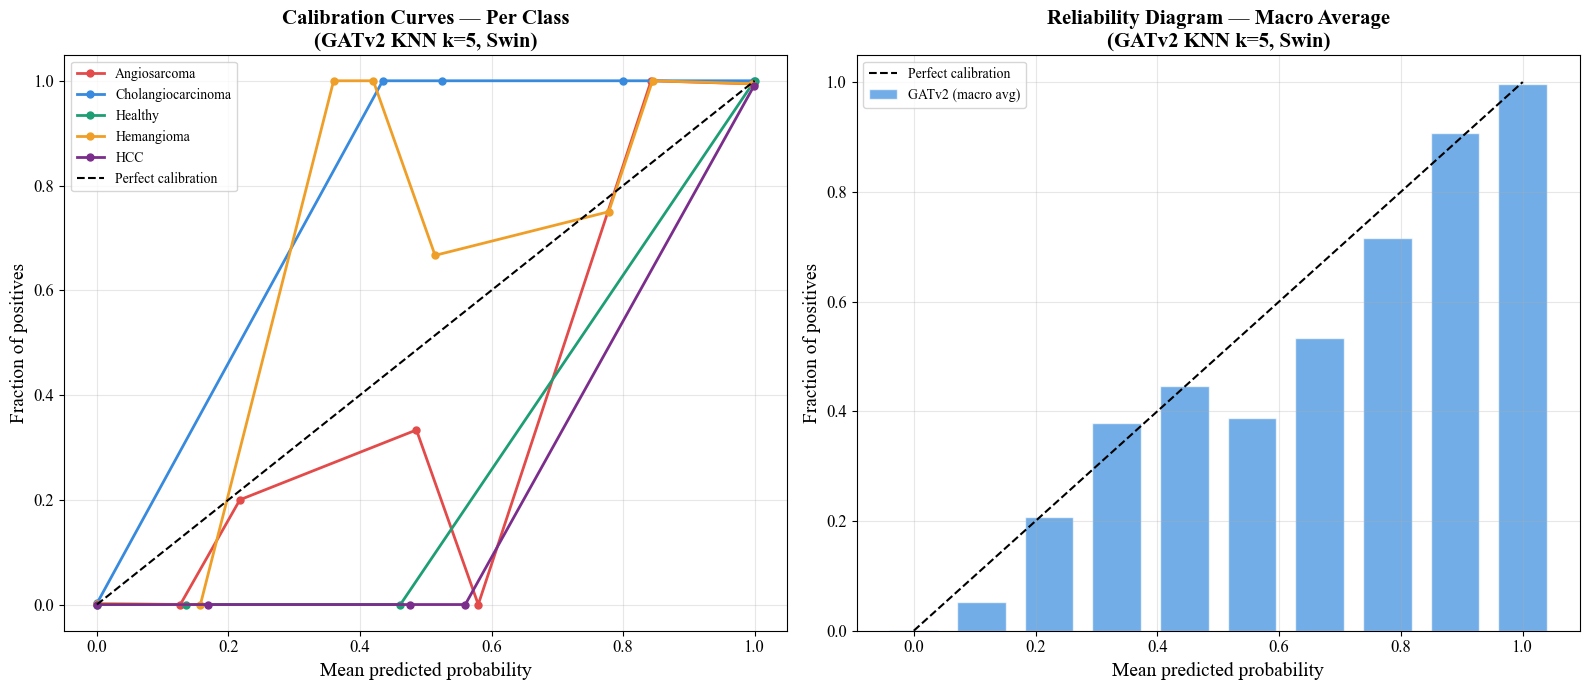

✅ Saved: Figure_Calibration_Curves.png


In [18]:
# Calibration Curves — New Figure
# ============================================================

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
matplotlib.rcParams['font.family'] = 'Times New Roman'

MRI_CLASSES = [
    'Angiosarcoma', 'Cholangiocarcinoma',
    'Healthy', 'Hemangioma', 'HCC'
]
COLORS = ['#E24B4A', '#378ADD', '#1D9E75', '#EF9F27', '#7B2D8B']

# Load best model results
y_true  = np.array(gat_results['knn_k5']['test_trues'])
y_probs = np.array(gat_results['knn_k5']['test_probs'])

y_true_bin = label_binarize(y_true, classes=list(range(5)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Per-class calibration ───────────────
for cls in range(5):
    prob_true, prob_pred = calibration_curve(
        y_true_bin[:, cls],
        y_probs[:, cls],
        n_bins=10
    )
    axes[0].plot(prob_pred, prob_true,
                 color=COLORS[cls], linewidth=2,
                 marker='o', markersize=5,
                 label=MRI_CLASSES[cls])

axes[0].plot([0, 1], [0, 1], 'k--',
             linewidth=1.5, label='Perfect calibration')
axes[0].set_title('Calibration Curves — Per Class\n(GATv2 KNN k=5, Swin)',
                  fontsize=15, fontweight='bold',
                  fontfamily='Times New Roman')
axes[0].set_xlabel('Mean predicted probability',
                   fontsize=14, fontfamily='Times New Roman')
axes[0].set_ylabel('Fraction of positives',
                   fontsize=14, fontfamily='Times New Roman')
axes[0].legend(fontsize=12, prop={'family': 'Times New Roman'})
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(labelsize=12)

# ── Right: Reliability diagram (macro) ────────
mean_prob_true = np.zeros(10)
mean_prob_pred = np.zeros(10)

for cls in range(5):
    prob_true, prob_pred = calibration_curve(
        y_true_bin[:, cls],
        y_probs[:, cls],
        n_bins=10
    )
    # Interpolate to fixed bins
    bins = np.linspace(0, 1, 10)
    interp = np.interp(bins, prob_pred, prob_true)
    mean_prob_true += interp
    mean_prob_pred += bins

mean_prob_true /= 5
mean_prob_pred /= 5

axes[1].bar(mean_prob_pred, mean_prob_true,
            width=0.08, alpha=0.7,
            color='#378ADD', label='GATv2 (macro avg)',
            edgecolor='white')
axes[1].plot([0, 1], [0, 1], 'k--',
             linewidth=1.5, label='Perfect calibration')
axes[1].set_title('Reliability Diagram — Macro Average\n(GATv2 KNN k=5, Swin)',
                  fontsize=15, fontweight='bold',
                  fontfamily='Times New Roman')
axes[1].set_xlabel('Mean predicted probability',
                   fontsize=14, fontfamily='Times New Roman')
axes[1].set_ylabel('Fraction of positives',
                   fontsize=14, fontfamily='Times New Roman')
axes[1].legend(fontsize=12, prop={'family': 'Times New Roman'})
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(labelsize=12)

plt.tight_layout()
save_path = os.path.join(FIGURES_PATH, 'Figure_Calibration_Curves.png')
plt.savefig(save_path, dpi=400, bbox_inches='tight')
plt.show()
print(f"✅ Saved: Figure_Calibration_Curves.png")

In [19]:
# 95% Confidence Intervals
# ============================================================

import scipy.stats as stats

def bootstrap_ci(y_true, y_pred, y_probs, metric_fn, n_bootstrap=1000, ci=0.95):
    np.random.seed(42)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        score = metric_fn(y_true[idx], y_pred[idx], y_probs[idx])
        scores.append(score)
    alpha = (1 - ci) / 2
    lower = np.percentile(scores, alpha * 100)
    upper = np.percentile(scores, (1 - alpha) * 100)
    return lower, upper

y_true  = np.array(gat_results['knn_k5']['test_trues'])
y_preds = np.array(gat_results['knn_k5']['test_preds'])
y_probs = np.array(gat_results['knn_k5']['test_probs'])

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

def acc_fn(yt, yp, ypr):
    return accuracy_score(yt, yp)

def f1_fn(yt, yp, ypr):
    return f1_score(yt, yp, average='macro', zero_division=0)

def auc_fn(yt, yp, ypr):
    yb = label_binarize(yt, classes=list(range(5)))
    return roc_auc_score(yb, ypr, multi_class='ovr')

print("=" * 55)
print("📊 95% CONFIDENCE INTERVALS — GATv2 KNN k=5 (Swin)")
print("=" * 55)

for name, fn in [('Accuracy', acc_fn),
                 ('Macro F1', f1_fn),
                 ('AUC-ROC', auc_fn)]:
    point = fn(y_true, y_preds, y_probs)
    lo, hi = bootstrap_ci(y_true, y_preds, y_probs, fn)
    print(f"{name:12s}: {point:.4f}  "
          f"(95% CI: {lo:.4f} – {hi:.4f})")

print("=" * 55)

📊 95% CONFIDENCE INTERVALS — GATv2 KNN k=5 (Swin)
Accuracy    : 0.9928  (95% CI: 0.9889 – 0.9961)
Macro F1    : 0.9928  (95% CI: 0.9889 – 0.9962)
AUC-ROC     : 0.9998  (95% CI: 0.9996 – 1.0000)


In [21]:
import os
print(os.listdir(r'E:\GNN Liver\results\embeddings'))

['clinical_assigned.csv', 'clinical_assigned_resnet.csv', 'cosine_subset_idx.npy', 'ct_embeddings.npy', 'ct_embed_index.csv', 'gat_cosine_095_embeddings.npy', 'gat_cosine_099_embeddings.npy', 'gat_knn_k10_embeddings.npy', 'gat_knn_k3_embeddings.npy', 'gat_knn_k5_embeddings.npy', 'gat_resnet_cosine_095_embeddings.npy', 'gat_resnet_cosine_099_embeddings.npy', 'gat_resnet_knn_k10_embeddings.npy', 'gat_resnet_knn_k3_embeddings.npy', 'gat_resnet_knn_k5_embeddings.npy', 'graph_cosine_07.pt', 'graph_cosine_08.pt', 'graph_cosine_095.pt', 'graph_cosine_099.pt', 'graph_k10.pt', 'graph_k3.pt', 'graph_k5.pt', 'graph_resnet_cosine_07.pt', 'graph_resnet_cosine_08.pt', 'graph_resnet_cosine_095.pt', 'graph_resnet_cosine_099.pt', 'graph_resnet_k10.pt', 'graph_resnet_k3.pt', 'graph_resnet_k5.pt', 'mri_embeddings.npy', 'mri_embeddings_resnet.npy', 'mri_embed_index.csv', 'mri_labels.npy', 'mri_labels_resnet.npy', 'node_features.npy', 'node_features_resnet.npy', 'node_labels.npy', 'node_labels_resnet.npy']

In [22]:
# Noise Robustness Test
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

print("=" * 50)
print("🔬 NOISE ROBUSTNESS TEST")
print("=" * 50)

X = np.load(r'E:\GNN Liver\results\embeddings\mri_embeddings.npy')
y = np.load(r'E:\GNN Liver\results\embeddings\mri_labels.npy')

noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20]

np.random.seed(42)
n = len(X)
idx = np.random.permutation(n)
train_idx = idx[:int(0.70*n)]
test_idx  = idx[int(0.85*n):]

X_train = X[train_idx]
y_train = y[train_idx]
X_test  = X[test_idx]
y_test  = y[test_idx]

print(f"\n{'Noise Level':>12} | {'Accuracy':>10}")
print("-" * 28)

for noise in noise_levels:
    X_test_noisy = X_test + np.random.normal(
        0, noise * X_test.std(), X_test.shape)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_noisy))
    print(f"{noise:>12.2f} | {acc:>10.4f}")

print("=" * 50)
print("✅ Noise robustness test complete!")

🔬 NOISE ROBUSTNESS TEST

 Noise Level |   Accuracy
----------------------------
        0.00 |     1.0000
        0.01 |     1.0000
        0.05 |     1.0000
        0.10 |     1.0000
        0.20 |     1.0000
✅ Noise robustness test complete!
